# Analisis Hubungan Tingkat Diskon dengan Nilai Penjualan dan Profit pada Transaksi Retail Berdasarkan Kategori Produk

## Projek Statistika dan Probabilitas

**Dataset:** Supermart Grocery Sales – Retail Analytics Dataset  
**Sumber Data:** Kaggle  
**Jenis Data:** Sekunder  
**Unit Observasi:** Satu transaksi retail  
**Jumlah Observasi:** 9.994 transaksi  
**Jumlah Variabel:** 11 variabel  

### Variabel Utama
- **Discount (X):** Tingkat diskon
- **Sales (Y1):** Nilai penjualan
- **Profit (Y2):** Nilai profit

### Variabel Pengelompokan
- **Category:** Kategori produk

## Tujuan Analisis

Analisis dilakukan untuk:

1. Mendeskripsikan karakteristik distribusi Sales, Discount, dan Profit serta membandingkannya berdasarkan Category.
2. Menganalisis hubungan antara tingkat Discount dengan Sales dan Profit.
3. Menghitung dan membandingkan probabilitas transaksi memiliki Profit tinggi berdasarkan tingkat Discount dan Category.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Memuat Dataset

Dataset yang digunakan merupakan data hasil preprocessing pada sheet **Data_Cleaning.**  
Sheet **Data_Asli** tetap dipertahankan sebagai data sumber dan tidak digunakan secara langsung dalam proses analisis statistik.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3TIA_02_SupermartGrocerySales.xlsx.xlsx to 3TIA_02_SupermartGrocerySales.xlsx (2).xlsx


In [ ]:
file_path = "3TIA_02_SupermartGrocerySales.xlsx.xlsx"
sheet_name = "Data_Cleaning"

In [ ]:
df = pd.read_excel(
    file_path,
    sheet_name=sheet_name
)

print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


In [ ]:
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,Tamil Nadu


In [ ]:
jumlah_baris, jumlah_kolom = df.shape

print("Jumlah observasi :", jumlah_baris)
print("Jumlah variabel  :", jumlah_kolom)

Jumlah observasi : 9994
Jumlah variabel  : 11


In [ ]:
print("Daftar variabel:")
for i, kolom in enumerate(df.columns, start=1):
    print(f"{i}. {kolom}")

Daftar variabel:
1. Order ID
2. Customer Name
3. Category
4. Sub Category
5. City
6. Order Date
7. Region
8. Sales
9. Discount
10. Profit
11. State


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Customer Name  9994 non-null   object        
 2   Category       9994 non-null   object        
 3   Sub Category   9994 non-null   object        
 4   City           9994 non-null   object        
 5   Order Date     9994 non-null   datetime64[ns]
 6   Region         9994 non-null   object        
 7   Sales          9994 non-null   int64         
 8   Discount       9994 non-null   float64       
 9   Profit         9994 non-null   float64       
 10  State          9994 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 859.0+ KB


In [ ]:
variabel_utama = ["Discount", "Sales", "Profit"]

df[variabel_utama].head()

,Discount,Sales,Profit
0,0.12,1254,401.28
1,0.18,749,149.80
2,0.21,2360,165.20
3,0.25,896,89.60
4,0.26,2355,918.45


In [ ]:
df[variabel_utama].dtypes

,0
Discount,float64
Sales,int64
Profit,float64


In [ ]:
df["Category"].unique()

array(['Oil & Masala', 'Beverages', 'Food Grains', 'Fruits & Veggies',
       'Bakery', 'Snacks', 'Eggs, Meat & Fish'], dtype=object)

In [ ]:
print("Jumlah kategori produk:", df["Category"].nunique())

Jumlah kategori produk: 7


## 2. Data Understanding

Tahap data understanding dilakukan untuk memahami struktur dataset, jenis variabel, jumlah nilai unik, cakupan waktu data, serta karakteristik awal variabel yang digunakan dalam projek.

In [ ]:
print(f"Jumlah observasi : {df.shape[0]}")
print(f"Jumlah variabel  : {df.shape[1]}")

Jumlah observasi : 9994
Jumlah variabel  : 11


In [ ]:
struktur_data = pd.DataFrame({
    "Variabel": df.columns,
    "Tipe Data Python": df.dtypes.astype(str)
})

struktur_data

,Variabel,Tipe Data Python
Order ID,Order ID,object
Customer Name,Customer Name,object
Category,Category,object
Sub Category,Sub Category,object
City,City,object
Order Date,Order Date,datetime64[ns]
Region,Region,object
Sales,Sales,int64
Discount,Discount,float64
Profit,Profit,float64


In [ ]:
jumlah_unik = df.nunique().reset_index()
jumlah_unik.columns = ["Variabel", "Jumlah Nilai Unik"]

jumlah_unik

,Variabel,Jumlah Nilai Unik
0,Order ID,9994
1,Customer Name,50
2,Category,7
3,Sub Category,23
4,City,24
5,Order Date,1236
6,Region,5
7,Sales,1989
8,Discount,26
9,Profit,8380


In [ ]:
print("Jumlah kategori produk:", df["Category"].nunique())
print("\nDaftar kategori produk:")

for kategori in sorted(df["Category"].unique()):
    print("-", kategori)

Jumlah kategori produk: 7

Daftar kategori produk:
- Bakery
- Beverages
- Eggs, Meat & Fish
- Food Grains
- Fruits & Veggies
- Oil & Masala
- Snacks


In [ ]:
frekuensi_category = (
    df["Category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Jumlah Transaksi")
)

frekuensi_category

,Category,Jumlah Transaksi
0,Snacks,1514
1,"Eggs, Meat & Fish",1490
2,Fruits & Veggies,1418
3,Bakery,1413
4,Beverages,1400
5,Food Grains,1398
6,Oil & Masala,1361


In [ ]:
tanggal_awal = df["Order Date"].min()
tanggal_akhir = df["Order Date"].max()

print("Tanggal transaksi pertama :", tanggal_awal.strftime("%d-%m-%Y"))
print("Tanggal transaksi terakhir :", tanggal_akhir.strftime("%d-%m-%Y"))

Tanggal transaksi pertama : 03-01-2015
Tanggal transaksi terakhir : 30-12-2018


### Variabel Utama Projek

Projek menggunakan tiga variabel utama, yaitu:

1. **Discount (X)** sebagai tingkat diskon.
2. **Sales (Y1)** sebagai nilai penjualan.
3. **Profit (Y2)** sebagai nilai profit.

Variabel **Category** digunakan sebagai variabel pendukung untuk mengelompokkan hasil analisis berdasarkan kategori produk.

In [ ]:
ringkasan_awal = pd.DataFrame({
    "Minimum": df[["Sales", "Discount", "Profit"]].min(),
    "Maximum": df[["Sales", "Discount", "Profit"]].max()
})

ringkasan_awal

,Minimum,Maximum
Sales,500.00,"2,500.00"
Discount,0.10,0.35
Profit,25.25,"1,120.95"


In [ ]:
print(f"Discount minimum : {df['Discount'].min():.0%}")
print(f"Discount maximum : {df['Discount'].max():.0%}")

Discount minimum : 10%
Discount maximum : 35%


In [ ]:
print("Jumlah nilai unik State:", df["State"].nunique())
print("Nilai State:", df["State"].unique())

Jumlah nilai unik State: 1
Nilai State: ['Tamil Nadu']


### Ringkasan Data Understanding

Berdasarkan tahap data understanding, dataset terdiri atas 9.994 transaksi dan 11 variabel. Variabel utama yang digunakan adalah Discount, Sales, dan Profit, sedangkan Category digunakan sebagai variabel pengelompokan.

Dataset memiliki 7 kategori produk dan mencakup transaksi dari 3 Januari 2015 hingga 30 Desember 2018. Variabel Sales, Discount, dan Profit telah tersimpan dalam tipe data numerik, sedangkan Order Date telah tersimpan dalam tipe datetime.

Variabel State hanya memiliki satu nilai, yaitu Tamil Nadu, sehingga tidak digunakan sebagai dasar analisis perbandingan.

## 3. Data Quality Check

Tahap data quality check dilakukan untuk memastikan dataset tidak memiliki missing value, duplikasi, kesalahan format, maupun nilai yang tidak sesuai dengan karakteristik variabel sebelum dilakukan analisis statistik.

In [ ]:
missing_value = df.isnull().sum().reset_index()
missing_value.columns = ["Variabel", "Jumlah Missing Value"]

missing_value

,Variabel,Jumlah Missing Value
0,Order ID,0
1,Customer Name,0
2,Category,0
3,Sub Category,0
4,City,0
5,Order Date,0
6,Region,0
7,Sales,0
8,Discount,0
9,Profit,0


In [ ]:
print("Total missing value:", df.isnull().sum().sum())

Total missing value: 0


In [ ]:
jumlah_duplikat = df.duplicated().sum()

print("Jumlah baris duplikat:", jumlah_duplikat)

Jumlah baris duplikat: 0


In [ ]:
duplikat_order_id = df["Order ID"].duplicated().sum()

print("Jumlah Order ID duplikat:", duplikat_order_id)

Jumlah Order ID duplikat: 0


In [ ]:
print("Jumlah Order ID unik:", df["Order ID"].nunique())

Jumlah Order ID unik: 9994


In [ ]:
sales_tidak_valid = (df["Sales"] <= 0).sum()

print("Jumlah Sales <= 0:", sales_tidak_valid)

Jumlah Sales <= 0: 0


In [ ]:
discount_tidak_valid = (
    (df["Discount"] < 0) |
    (df["Discount"] > 1)
).sum()

print("Jumlah Discount di luar rentang 0–1:", discount_tidak_valid)

Jumlah Discount di luar rentang 0–1: 0


In [ ]:
print("Jumlah Profit kosong:", df["Profit"].isnull().sum())
print("Tipe data Profit:", df["Profit"].dtype)

Jumlah Profit kosong: 0
Tipe data Profit: float64


In [ ]:
for kolom in ["Sales", "Discount", "Profit"]:
    print(f"{kolom}")
    print("Minimum :", df[kolom].min())
    print("Maximum :", df[kolom].max())
    print()

Sales
Minimum : 500
Maximum : 2500

Discount
Minimum : 0.1
Maximum : 0.35

Profit
Minimum : 25.25
Maximum : 1120.95



In [ ]:
print(f"Discount minimum : {df['Discount'].min():.0%}")
print(f"Discount maximum : {df['Discount'].max():.0%}")

Discount minimum : 10%
Discount maximum : 35%


In [ ]:
print("Missing Order Date :", df["Order Date"].isnull().sum())
print("Tanggal minimum    :", df["Order Date"].min())
print("Tanggal maksimum   :", df["Order Date"].max())
print("Tipe data          :", df["Order Date"].dtype)

Missing Order Date : 0
Tanggal minimum    : 2015-01-03 00:00:00
Tanggal maksimum   : 2018-12-30 00:00:00
Tipe data          : datetime64[ns]


In [ ]:
kolom_kategorik = [
    "Order ID",
    "Customer Name",
    "Category",
    "Sub Category",
    "City",
    "Region",
    "State"
]

for kolom in kolom_kategorik:
    jumlah_spasi = (
        df[kolom].astype(str).str.strip()
        != df[kolom].astype(str)
    ).sum()

    print(f"{kolom}: {jumlah_spasi}")

Order ID: 0
Customer Name: 0
Category: 0
Sub Category: 0
City: 0
Region: 0
State: 0


In [ ]:
print(df["Category"].value_counts())

Category
Snacks               1514
Eggs, Meat & Fish    1490
Fruits & Veggies     1418
Bakery               1413
Beverages            1400
Food Grains          1398
Oil & Masala         1361
Name: count, dtype: int64


In [ ]:
print("Total transaksi:", df["Category"].value_counts().sum())

Total transaksi: 9994


In [ ]:
kolom_konstan = [
    kolom
    for kolom in df.columns
    if df[kolom].nunique() == 1
]

print("Kolom dengan satu nilai unik:", kolom_konstan)

Kolom dengan satu nilai unik: ['State']


In [ ]:
quality_check = pd.DataFrame({
    "Pemeriksaan": [
        "Missing value",
        "Duplikasi seluruh baris",
        "Duplikasi Order ID",
        "Sales <= 0",
        "Discount di luar 0–1",
        "Missing Order Date",
        "Spasi berlebih kategori"
    ],
    "Jumlah Masalah": [
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["Order ID"].duplicated().sum(),
        (df["Sales"] <= 0).sum(),
        ((df["Discount"] < 0) | (df["Discount"] > 1)).sum(),
        df["Order Date"].isnull().sum(),
        sum(
            (
                df[kolom].astype(str).str.strip()
                != df[kolom].astype(str)
            ).sum()
            for kolom in kolom_kategorik
        )
    ]
})

quality_check

,Pemeriksaan,Jumlah Masalah
0,Missing value,0
1,Duplikasi seluruh baris,0
2,Duplikasi Order ID,0
3,Sales <= 0,0
4,Discount di luar 0–1,0
5,Missing Order Date,0
6,Spasi berlebih kategori,0


### Kesimpulan Data Quality Check

Berdasarkan pemeriksaan kualitas data, tidak ditemukan missing value, duplikasi seluruh baris, maupun duplikasi Order ID pada dataset. Variabel Sales, Discount, dan Profit telah tersimpan dalam format numerik, sedangkan Order Date telah tersimpan dalam format datetime.

Seluruh nilai Sales bernilai positif dan seluruh nilai Discount berada pada rentang 0 hingga 1. Tidak ditemukan spasi berlebih pada variabel kategorik. Variabel State memiliki satu nilai unik, yaitu Tamil Nadu, sehingga tetap dipertahankan sebagai bagian dari dataset sumber tetapi tidak digunakan dalam analisis perbandingan.

Dengan demikian, dataset dinilai siap digunakan pada tahap analisis statistik berikutnya tanpa perlu menghapus observasi.

## 4. Preprocessing Data

Tahap preprocessing dilakukan untuk memastikan data memiliki format yang konsisten dan siap digunakan dalam analisis statistik. Dataset asli tetap dipertahankan pada sheet `Data_Asli`, sedangkan dataset hasil preprocessing digunakan dari sheet `Data_Cleaning`.

Preprocessing utama dilakukan pada variabel `Order Date` dengan mengubah data tanggal yang sebelumnya tersimpan sebagai teks menjadi format tanggal Excel yang konsisten. Tidak terdapat observasi yang dihapus selama proses preprocessing.

In [ ]:
df_asli = pd.read_excel(
    file_path,
    sheet_name="Data_Asli"
)

print("Ukuran Data_Asli     :", df_asli.shape)
print("Ukuran Data_Cleaning :", df.shape)

Ukuran Data_Asli     : (9994, 11)
Ukuran Data_Cleaning : (9994, 11)


In [ ]:
print("Tipe Order Date pada Data_Asli     :", df_asli["Order Date"].dtype)
print("Tipe Order Date pada Data_Cleaning :", df["Order Date"].dtype)

Tipe Order Date pada Data_Asli     : object
Tipe Order Date pada Data_Cleaning : datetime64[ns]


In [ ]:
perbandingan_tanggal = pd.DataFrame({
    "Order Date Asli": df_asli["Order Date"].head(10),
    "Order Date Cleaning": df["Order Date"].head(10)
})

perbandingan_tanggal

,Order Date Asli,Order Date Cleaning
0,11-08-2017,2017-11-08
1,11-08-2017,2017-11-08
2,06-12-2017,2017-06-12
3,10-11-2016,2016-10-11
4,10-11-2016,2016-10-11
5,06-09-2015,2015-06-09
6,06-09-2015,2015-06-09
7,06-09-2015,2015-06-09
8,06-09-2015,2015-06-09
9,06-09-2015,2015-06-09


In [ ]:
kolom_non_tanggal = [
    kolom for kolom in df.columns
    if kolom != "Order Date"
]

data_sama = df_asli[kolom_non_tanggal].equals(
    df[kolom_non_tanggal]
)

print("Apakah seluruh kolom selain Order Date tetap sama?", data_sama)

Apakah seluruh kolom selain Order Date tetap sama? True


### Pemeriksaan Outlier

Pemeriksaan outlier dilakukan pada tiga variabel utama numerik, yaitu Sales, Discount, dan Profit, menggunakan metode Interquartile Range (IQR). Nilai yang berada di luar batas Q1 − 1,5×IQR dan Q3 + 1,5×IQR ditandai sebagai potential outlier.

Outlier yang terdeteksi tidak langsung dihapus karena nilai ekstrem secara statistik belum tentu menunjukkan kesalahan data.

In [ ]:
variabel_numerik = ["Sales", "Discount", "Profit"]

hasil_outlier = []

for kolom in variabel_numerik:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    jumlah_outlier = (
        (df[kolom] < batas_bawah) |
        (df[kolom] > batas_atas)
    ).sum()

    hasil_outlier.append({
        "Variabel": kolom,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": batas_bawah,
        "Batas Atas": batas_atas,
        "Jumlah Outlier": jumlah_outlier
    })

outlier_summary = pd.DataFrame(hasil_outlier)

outlier_summary

,Variabel,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,Sales,"1,000.00","1,994.75",994.75,-492.12,"3,486.88",0
1,Discount,0.16,0.29,0.13,-0.03,0.48,0
2,Profit,180.02,525.63,345.61,-338.38,"1,044.04",43


In [ ]:
Q1_profit = df["Profit"].quantile(0.25)
Q3_profit = df["Profit"].quantile(0.75)
IQR_profit = Q3_profit - Q1_profit

batas_atas_profit = Q3_profit + 1.5 * IQR_profit
batas_bawah_profit = Q1_profit - 1.5 * IQR_profit

outlier_profit = df[
    (df["Profit"] < batas_bawah_profit) |
    (df["Profit"] > batas_atas_profit)
]

persentase_outlier_profit = (
    len(outlier_profit) / len(df)
) * 100

print("Jumlah outlier Profit :", len(outlier_profit))
print(f"Persentase outlier    : {persentase_outlier_profit:.2f}%")

Jumlah outlier Profit : 43
Persentase outlier    : 0.43%


In [ ]:
outlier_profit[
    ["Order ID", "Category", "Sales", "Discount", "Profit"]
].sort_values(
    by="Profit",
    ascending=False
).head(10)

,Order ID,Category,Sales,Discount,Profit
3159,OD3160,Bakery,2491,0.26,"1,120.95"
3467,OD3468,Fruits & Veggies,2490,0.24,"1,120.50"
3436,OD3437,Bakery,2469,0.29,"1,111.05"
8134,OD8135,Bakery,2452,0.18,"1,103.40"
9782,OD9783,Snacks,2450,0.21,"1,102.50"
1115,OD1116,"Eggs, Meat & Fish",2439,0.30,"1,097.55"
4943,OD4944,Beverages,2434,0.29,"1,095.30"
1304,OD1305,Fruits & Veggies,2432,0.34,"1,094.40"
1807,OD1808,Bakery,2429,0.11,"1,093.05"
3144,OD3145,Oil & Masala,2478,0.13,"1,090.32"


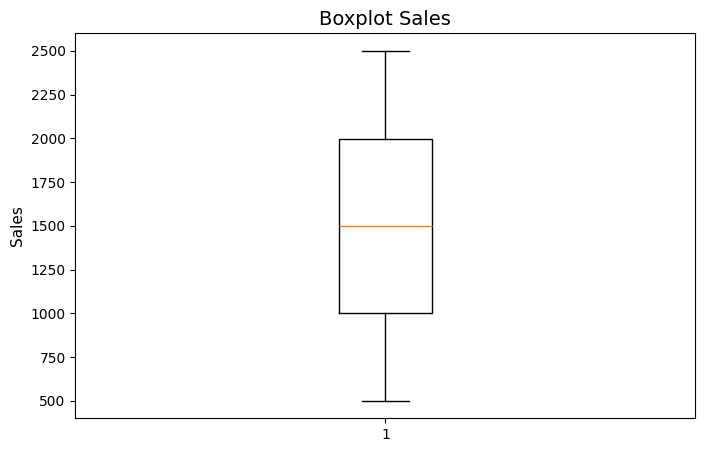

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Sales"].dropna())
plt.title("Boxplot Sales")
plt.ylabel("Sales")
plt.show()

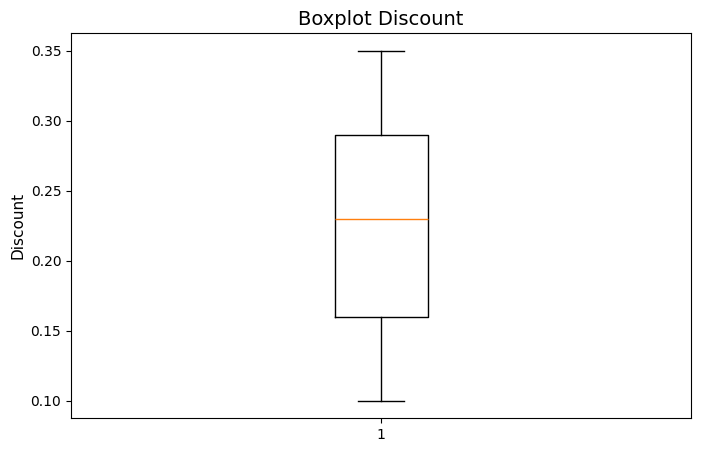

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Discount"].dropna())
plt.title("Boxplot Discount")
plt.ylabel("Discount")
plt.show()

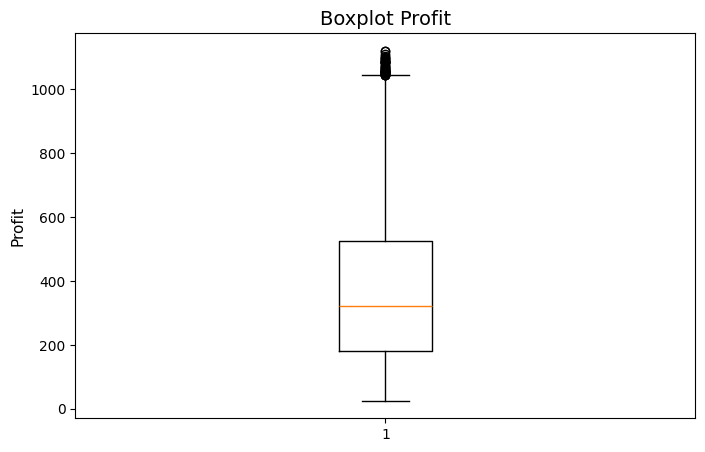

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Profit"].dropna())
plt.title("Boxplot Profit")
plt.ylabel("Profit")
plt.show()

### Keputusan terhadap Outlier

Berdasarkan metode IQR, tidak ditemukan outlier pada variabel Sales dan Discount. Pada variabel Profit ditemukan 43 observasi yang berada di atas batas atas IQR.

Observasi tersebut tetap dipertahankan dalam analisis karena tidak ditemukan indikasi kesalahan input, missing value, maupun ketidaksesuaian format data. Nilai tersebut diperlakukan sebagai variasi alami dalam dataset dan bukan sebagai data yang harus dihapus.

Dengan demikian, tidak terdapat observasi yang dihapus pada tahap preprocessing dan jumlah data yang digunakan tetap sebanyak 9.994 transaksi.

In [ ]:
ringkasan_preprocessing = pd.DataFrame({
    "Tahap": [
        "Standardisasi Order Date",
        "Penghapusan missing value",
        "Penghapusan duplikasi",
        "Penghapusan outlier",
        "Jumlah data awal",
        "Jumlah data akhir"
    ],
    "Hasil": [
        "Dilakukan",
        "Tidak diperlukan",
        "Tidak diperlukan",
        "Tidak dilakukan",
        len(df_asli),
        len(df)
    ]
})

ringkasan_preprocessing

,Tahap,Hasil
0,Standardisasi Order Date,Dilakukan
1,Penghapusan missing value,Tidak diperlukan
2,Penghapusan duplikasi,Tidak diperlukan
3,Penghapusan outlier,Tidak dilakukan
4,Jumlah data awal,9994
5,Jumlah data akhir,9994


### Kesimpulan Preprocessing

Preprocessing dilakukan dengan menstandardisasi variabel Order Date dari tipe teks menjadi tipe datetime tanpa mengubah variabel lainnya. Tidak ditemukan missing value maupun duplikasi sehingga tidak diperlukan penghapusan data.

Berdasarkan metode IQR, terdapat 43 potential outlier pada variabel Profit, sedangkan Sales dan Discount tidak memiliki outlier. Observasi tersebut tetap dipertahankan karena tidak terdapat bukti bahwa nilai tersebut merupakan kesalahan data.

Setelah preprocessing, dataset tetap terdiri atas 9.994 transaksi dan 11 variabel dan siap digunakan untuk analisis statistik.

## 5. Statistik Deskriptif

Statistik deskriptif digunakan untuk memberikan gambaran awal mengenai karakteristik tiga variabel utama, yaitu Sales, Discount, dan Profit. Ukuran yang digunakan meliputi jumlah observasi, mean, median, standar deviasi, nilai minimum, kuartil pertama (Q1), kuartil ketiga (Q3), dan nilai maksimum.

Analisis deskriptif juga dilakukan berdasarkan Category untuk melihat perbedaan karakteristik antar kategori produk.

In [ ]:
variabel_utama = ["Sales", "Discount", "Profit"]

statistik_deskriptif = pd.DataFrame({
    "N": df[variabel_utama].count(),
    "Mean": df[variabel_utama].mean(),
    "Median": df[variabel_utama].median(),
    "Std Dev": df[variabel_utama].std(),
    "Minimum": df[variabel_utama].min(),
    "Q1": df[variabel_utama].quantile(0.25),
    "Q3": df[variabel_utama].quantile(0.75),
    "Maximum": df[variabel_utama].max()
})

statistik_deskriptif.round(4)

,N,Mean,Median,Std Dev,Minimum,Q1,Q3,Maximum
Sales,9994,"1,496.60","1,498.00",577.56,500.00,"1,000.00","1,994.75","2,500.00"
Discount,9994,0.23,0.23,0.07,0.10,0.16,0.29,0.35
Profit,9994,374.94,320.78,239.93,25.25,180.02,525.63,"1,120.95"


In [ ]:
print("=== SALES ===")
print(f"Mean       : {df['Sales'].mean():.2f}")
print(f"Median     : {df['Sales'].median():.2f}")
print(f"Std Dev    : {df['Sales'].std():.2f}")
print(f"Minimum    : {df['Sales'].min():.2f}")
print(f"Q1         : {df['Sales'].quantile(0.25):.2f}")
print(f"Q3         : {df['Sales'].quantile(0.75):.2f}")
print(f"Maximum    : {df['Sales'].max():.2f}")

print("\n=== DISCOUNT ===")
print(f"Mean       : {df['Discount'].mean():.2%}")
print(f"Median     : {df['Discount'].median():.2%}")
print(f"Std Dev    : {df['Discount'].std():.2%}")
print(f"Minimum    : {df['Discount'].min():.2%}")
print(f"Q1         : {df['Discount'].quantile(0.25):.2%}")
print(f"Q3         : {df['Discount'].quantile(0.75):.2%}")
print(f"Maximum    : {df['Discount'].max():.2%}")

print("\n=== PROFIT ===")
print(f"Mean       : {df['Profit'].mean():.2f}")
print(f"Median     : {df['Profit'].median():.2f}")
print(f"Std Dev    : {df['Profit'].std():.2f}")
print(f"Minimum    : {df['Profit'].min():.2f}")
print(f"Q1         : {df['Profit'].quantile(0.25):.2f}")
print(f"Q3         : {df['Profit'].quantile(0.75):.2f}")
print(f"Maximum    : {df['Profit'].max():.2f}")

=== SALES ===
Mean       : 1496.60
Median     : 1498.00
Std Dev    : 577.56
Minimum    : 500.00
Q1         : 1000.00
Q3         : 1994.75
Maximum    : 2500.00

=== DISCOUNT ===
Mean       : 22.68%
Median     : 23.00%
Std Dev    : 7.46%
Minimum    : 10.00%
Q1         : 16.00%
Q3         : 29.00%
Maximum    : 35.00%

=== PROFIT ===
Mean       : 374.94
Median     : 320.78
Std Dev    : 239.93
Minimum    : 25.25
Q1         : 180.02
Q3         : 525.63
Maximum    : 1120.95


In [ ]:
rentang_data = pd.DataFrame({
    "Minimum": df[variabel_utama].min(),
    "Maximum": df[variabel_utama].max(),
    "Range": (
        df[variabel_utama].max()
        - df[variabel_utama].min()
    )
})

rentang_data.round(4)

,Minimum,Maximum,Range
Sales,500.00,"2,500.00","2,000.00"
Discount,0.10,0.35,0.25
Profit,25.25,"1,120.95","1,095.70"


### Interpretasi Statistik Deskriptif

Berdasarkan 9.994 transaksi, variabel Sales memiliki rata-rata sebesar 1.496,60 dan median sebesar 1.498,00. Nilai Sales berada pada rentang 500 hingga 2.500 dengan standar deviasi sebesar 577,56.

Variabel Discount memiliki rata-rata sebesar 22,68% dan median sebesar 23%. Sebanyak 50% observasi berada di antara Q1 sebesar 16% dan Q3 sebesar 29%. Tingkat diskon minimum adalah 10% dan maksimum 35%.

Variabel Profit memiliki rata-rata sebesar 374,94 dan median sebesar 320,78, dengan nilai minimum 25,25 dan maksimum 1.120,95. Standar deviasi Profit sebesar 239,93 menunjukkan adanya variasi nilai profit antar transaksi.

Perbedaan antara mean dan median Profit memberikan indikasi awal bahwa distribusi Profit mungkin tidak sepenuhnya simetris. Bentuk distribusi tersebut akan diperiksa lebih lanjut melalui visualisasi dan ukuran distribusi pada tahap berikutnya.

In [ ]:
deskriptif_category = (
    df.groupby("Category")
    .agg(
        N=("Order ID", "count"),
        Mean_Sales=("Sales", "mean"),
        Median_Sales=("Sales", "median"),
        Mean_Discount=("Discount", "mean"),
        Median_Discount=("Discount", "median"),
        Mean_Profit=("Profit", "mean"),
        Median_Profit=("Profit", "median")
    )
    .reset_index()
)

# Mengubah tampilan Discount menjadi persen
deskriptif_category["Mean_Discount (%)"] = (
    deskriptif_category["Mean_Discount"] * 100
)

deskriptif_category["Median_Discount (%)"] = (
    deskriptif_category["Median_Discount"] * 100
)

deskriptif_category = deskriptif_category[
    [
        "Category",
        "N",
        "Mean_Sales",
        "Median_Sales",
        "Mean_Discount (%)",
        "Median_Discount (%)",
        "Mean_Profit",
        "Median_Profit"
    ]
]

deskriptif_category.round(2)

,Category,N,Mean_Sales,Median_Sales,Mean_Discount (%),Median_Discount (%),Mean_Profit,Median_Profit
0,Bakery,1413,"1,494.89","1,501.00",22.54,23.00,374.04,313.28
1,Beverages,1400,"1,489.51","1,512.00",23.03,23.00,375.43,326.63
2,"Eggs, Meat & Fish",1490,"1,521.75","1,522.00",22.78,23.00,380.78,331.50
3,Food Grains,1398,"1,513.07","1,541.50",22.85,23.00,378.51,318.30
4,Fruits & Veggies,1418,"1,481.47","1,450.00",22.93,23.00,374.05,327.51
5,Oil & Masala,1361,"1,497.75","1,495.00",22.45,23.00,365.83,309.12
6,Snacks,1514,"1,477.90","1,460.00",22.20,22.00,375.28,317.60


In [ ]:
kategori_sales_tertinggi = deskriptif_category.loc[
    deskriptif_category["Mean_Sales"].idxmax()
]

kategori_sales_terendah = deskriptif_category.loc[
    deskriptif_category["Mean_Sales"].idxmin()
]

kategori_profit_tertinggi = deskriptif_category.loc[
    deskriptif_category["Mean_Profit"].idxmax()
]

kategori_profit_terendah = deskriptif_category.loc[
    deskriptif_category["Mean_Profit"].idxmin()
]

kategori_discount_tertinggi = deskriptif_category.loc[
    deskriptif_category["Mean_Discount (%)"].idxmax()
]

kategori_discount_terendah = deskriptif_category.loc[
    deskriptif_category["Mean_Discount (%)"].idxmin()
]

print(
    "Mean Sales tertinggi :",
    kategori_sales_tertinggi["Category"],
    f"({kategori_sales_tertinggi['Mean_Sales']:.2f})"
)

print(
    "Mean Sales terendah  :",
    kategori_sales_terendah["Category"],
    f"({kategori_sales_terendah['Mean_Sales']:.2f})"
)

print(
    "\nMean Profit tertinggi:",
    kategori_profit_tertinggi["Category"],
    f"({kategori_profit_tertinggi['Mean_Profit']:.2f})"
)

print(
    "Mean Profit terendah :",
    kategori_profit_terendah["Category"],
    f"({kategori_profit_terendah['Mean_Profit']:.2f})"
)

print(
    "\nMean Discount tertinggi:",
    kategori_discount_tertinggi["Category"],
    f"({kategori_discount_tertinggi['Mean_Discount (%)']:.2f}%)"
)

print(
    "Mean Discount terendah :",
    kategori_discount_terendah["Category"],
    f"({kategori_discount_terendah['Mean_Discount (%)']:.2f}%)"
)

Mean Sales tertinggi : Eggs, Meat & Fish (1521.75)
Mean Sales terendah  : Snacks (1477.90)

Mean Profit tertinggi: Eggs, Meat & Fish (380.78)
Mean Profit terendah : Oil & Masala (365.83)

Mean Discount tertinggi: Beverages (23.03%)
Mean Discount terendah : Snacks (22.20%)


### Interpretasi Berdasarkan Category

Secara deskriptif, rata-rata Sales tertinggi terdapat pada kategori Eggs, Meat & Fish sebesar 1.521,75, sedangkan rata-rata Sales terendah terdapat pada kategori Snacks sebesar 1.477,90.

Rata-rata Profit tertinggi juga terdapat pada kategori Eggs, Meat & Fish sebesar 380,78, sedangkan rata-rata Profit terendah terdapat pada kategori Oil & Masala sebesar 365,83.

Untuk Discount, rata-rata tingkat diskon tertinggi terdapat pada kategori Beverages sebesar 23,03%, sedangkan yang terendah terdapat pada kategori Snacks sebesar 22,20%.

Hasil tersebut menunjukkan adanya perbedaan nilai deskriptif antar kategori produk. Namun, perbedaan rata-rata tersebut belum dapat langsung diartikan sebagai perbedaan yang signifikan secara statistik. Distribusi masing-masing variabel akan diperiksa lebih lanjut melalui visualisasi pada tahap berikutnya.

## 6. Analisis Distribusi dan Visualisasi

Analisis distribusi dilakukan untuk memahami bentuk penyebaran Sales, Discount, dan Profit. Pemeriksaan dilakukan menggunakan histogram, boxplot, dan nilai skewness.

Histogram digunakan untuk melihat pola distribusi data, boxplot digunakan untuk melihat median, penyebaran, dan potential outlier, sedangkan skewness digunakan untuk mengukur tingkat kemencengan distribusi.

In [ ]:
# Warna pastel untuk setiap variabel
warna_sales = "#A8D8EA"      # biru pastel
warna_discount = "#F8BBD0"   # pink pastel
warna_profit = "#CDB4DB"     # ungu pastel

warna_mean = "#FF8FAB"
warna_median = "#6C63FF"

# Pengaturan tampilan umum grafik
plt.rcParams["figure.figsize"] = (9, 5.5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [ ]:
skewness = df[["Sales", "Discount", "Profit"]].skew()

skewness_table = pd.DataFrame({
    "Variabel": skewness.index,
    "Skewness": skewness.values
})

skewness_table["Skewness"] = skewness_table["Skewness"].round(4)

skewness_table

,Variabel,Skewness
0,Sales,0.00
1,Discount,-0.03
2,Profit,0.77


In [ ]:
import os

os.makedirs("output_grafik", exist_ok=True)

print("Folder output_grafik siap digunakan.")

Folder output_grafik siap digunakan.


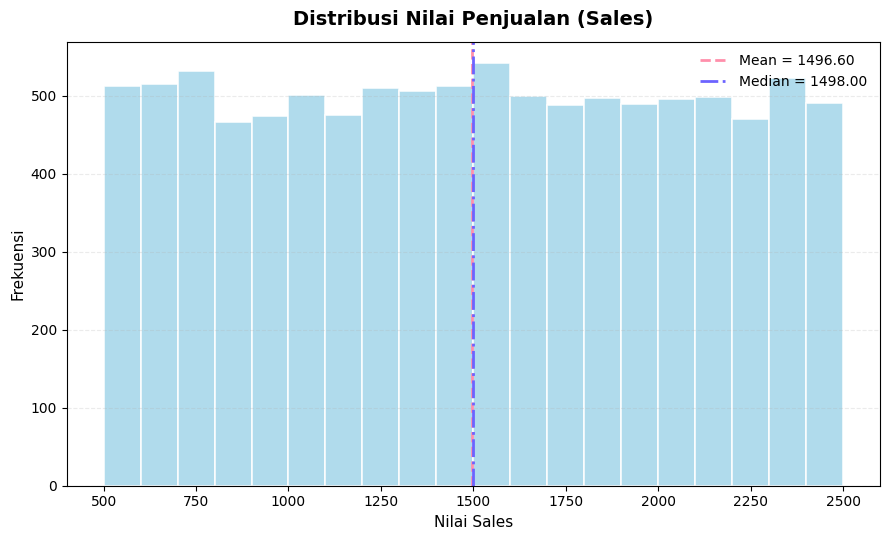

In [ ]:
plt.figure(figsize=(9, 5.5))

plt.hist(
    df["Sales"],
    bins=20,
    color=warna_sales,
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9
)

# Garis mean
plt.axvline(
    df["Sales"].mean(),
    color=warna_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Sales'].mean():.2f}"
)

# Garis median
plt.axvline(
    df["Sales"].median(),
    color=warna_median,
    linestyle="-.",
    linewidth=2,
    label=f"Median = {df['Sales'].median():.2f}"
)

plt.title(
    "Distribusi Nilai Penjualan (Sales)",
    fontweight="bold",
    pad=12
)

plt.xlabel("Nilai Sales")
plt.ylabel("Frekuensi")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "output_grafik/histogram_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

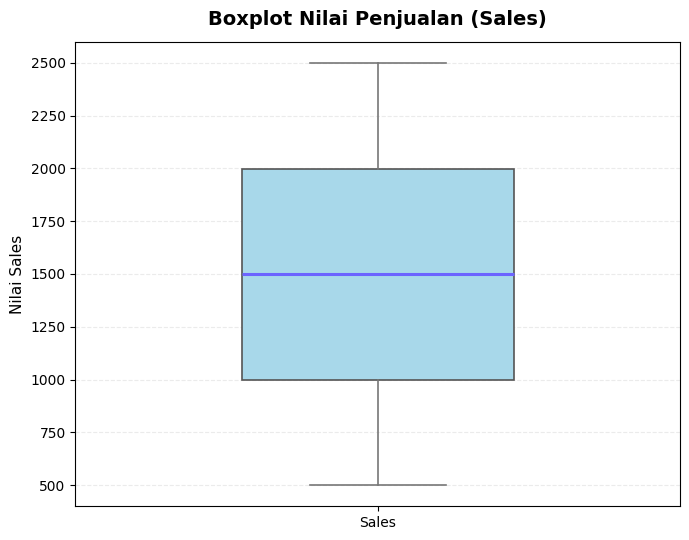

In [ ]:
plt.figure(figsize=(7, 5.5))

box = plt.boxplot(
    df["Sales"].dropna(),
    patch_artist=True,
    widths=0.45,
    boxprops=dict(
        facecolor=warna_sales,
        edgecolor="#555555",
        linewidth=1.2
    ),
    medianprops=dict(
        color=warna_median,
        linewidth=2.2
    ),
    whiskerprops=dict(
        color="#777777",
        linewidth=1.2
    ),
    capprops=dict(
        color="#777777",
        linewidth=1.2
    )
)

plt.title(
    "Boxplot Nilai Penjualan (Sales)",
    fontweight="bold",
    pad=12
)

plt.ylabel("Nilai Sales")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.xticks([1], ["Sales"])

plt.tight_layout()

plt.savefig(
    "output_grafik/boxplot_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Distribusi Sales

Distribusi Sales menunjukkan pola yang relatif simetris. Mean Sales sebesar 1.496,60 sangat dekat dengan median sebesar 1.498,00. Nilai skewness sebesar 0,0009 juga sangat dekat dengan nol sehingga tidak menunjukkan kemencengan distribusi yang berarti.

Sales berada pada rentang 500 hingga 2.500. Berdasarkan metode IQR, tidak ditemukan potential outlier pada variabel Sales.

In [ ]:
from matplotlib.ticker import PercentFormatter

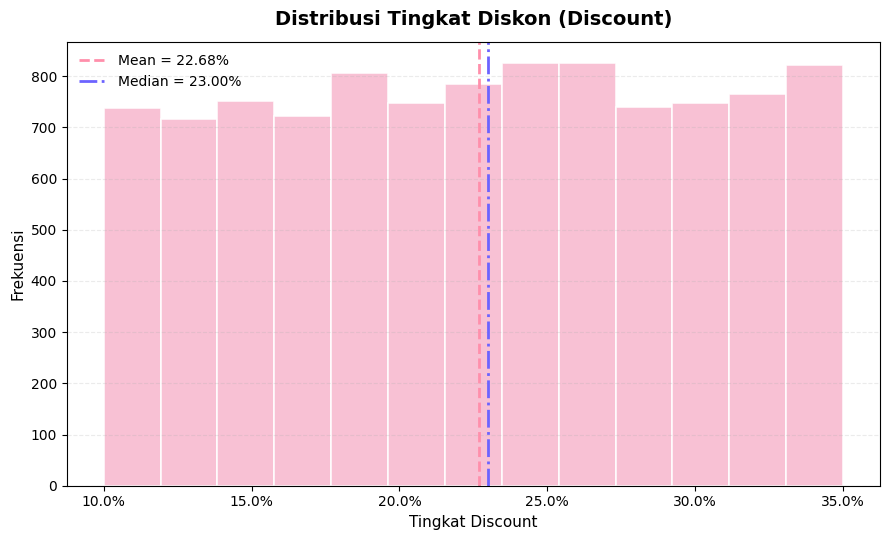

In [ ]:
plt.figure(figsize=(9, 5.5))

plt.hist(
    df["Discount"],
    bins=13,
    color=warna_discount,
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9
)

plt.axvline(
    df["Discount"].mean(),
    color=warna_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Discount'].mean():.2%}"
)

plt.axvline(
    df["Discount"].median(),
    color=warna_median,
    linestyle="-.",
    linewidth=2,
    label=f"Median = {df['Discount'].median():.2%}"
)

plt.title(
    "Distribusi Tingkat Diskon (Discount)",
    fontweight="bold",
    pad=12
)

plt.xlabel("Tingkat Discount")
plt.ylabel("Frekuensi")

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "output_grafik/histogram_discount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

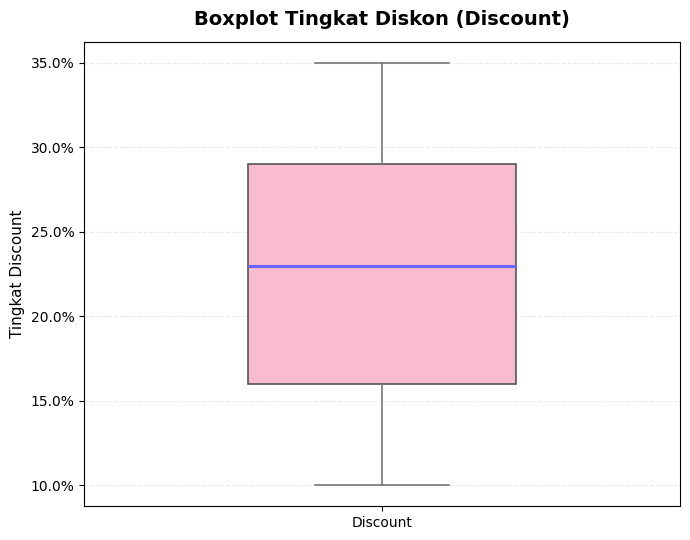

In [ ]:
plt.figure(figsize=(7, 5.5))

plt.boxplot(
    df["Discount"].dropna(),
    patch_artist=True,
    widths=0.45,
    boxprops=dict(
        facecolor=warna_discount,
        edgecolor="#555555",
        linewidth=1.2
    ),
    medianprops=dict(
        color=warna_median,
        linewidth=2.2
    ),
    whiskerprops=dict(
        color="#777777",
        linewidth=1.2
    ),
    capprops=dict(
        color="#777777",
        linewidth=1.2
    )
)

plt.title(
    "Boxplot Tingkat Diskon (Discount)",
    fontweight="bold",
    pad=12
)

plt.ylabel("Tingkat Discount")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.xticks([1], ["Discount"])

plt.tight_layout()

plt.savefig(
    "output_grafik/boxplot_discount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Distribusi Discount

Discount berada pada rentang 10% hingga 35%, dengan mean sebesar 22,68% dan median sebesar 23%.

Nilai skewness sebesar -0,0265 sangat dekat dengan nol sehingga distribusi Discount relatif simetris dan tidak menunjukkan kemencengan yang kuat. Berdasarkan metode IQR, tidak ditemukan potential outlier pada variabel Discount.

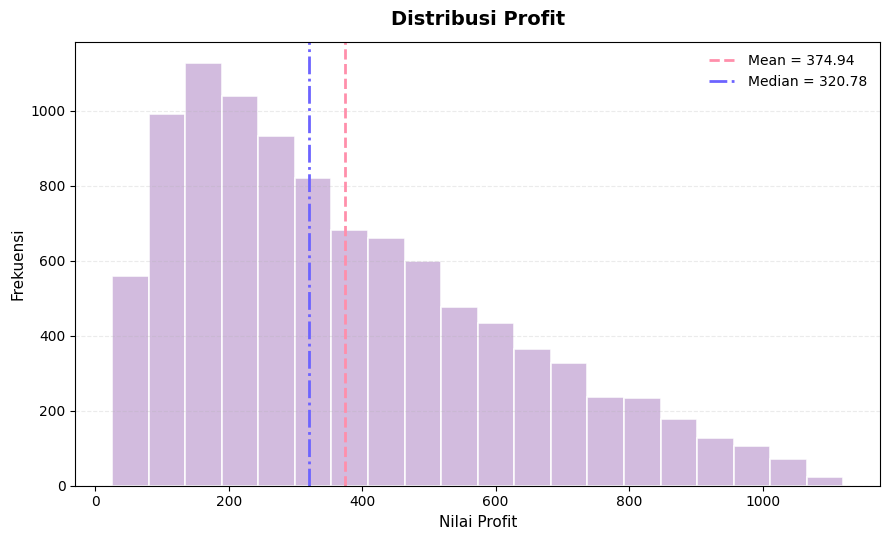

In [ ]:
plt.figure(figsize=(9, 5.5))

plt.hist(
    df["Profit"],
    bins=20,
    color=warna_profit,
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9
)

plt.axvline(
    df["Profit"].mean(),
    color=warna_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Profit'].mean():.2f}"
)

plt.axvline(
    df["Profit"].median(),
    color=warna_median,
    linestyle="-.",
    linewidth=2,
    label=f"Median = {df['Profit'].median():.2f}"
)

plt.title(
    "Distribusi Profit",
    fontweight="bold",
    pad=12
)

plt.xlabel("Nilai Profit")
plt.ylabel("Frekuensi")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "output_grafik/histogram_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

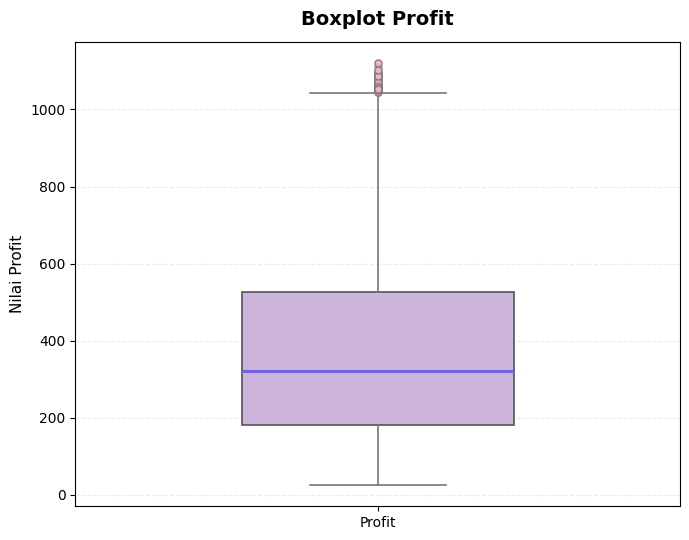

In [ ]:
plt.figure(figsize=(7, 5.5))

plt.boxplot(
    df["Profit"].dropna(),
    patch_artist=True,
    widths=0.45,
    boxprops=dict(
        facecolor=warna_profit,
        edgecolor="#555555",
        linewidth=1.2
    ),
    medianprops=dict(
        color=warna_median,
        linewidth=2.2
    ),
    whiskerprops=dict(
        color="#777777",
        linewidth=1.2
    ),
    capprops=dict(
        color="#777777",
        linewidth=1.2
    ),
    flierprops=dict(
        marker="o",
        markerfacecolor="#FFB3C6",
        markeredgecolor="#777777",
        markersize=5,
        alpha=0.7
    )
)

plt.title(
    "Boxplot Profit",
    fontweight="bold",
    pad=12
)

plt.ylabel("Nilai Profit")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.xticks([1], ["Profit"])

plt.tight_layout()

plt.savefig(
    "output_grafik/boxplot_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Distribusi Profit

Distribusi Profit menunjukkan kemencengan ke arah kanan (positive skew). Mean Profit sebesar 374,94 lebih tinggi daripada median sebesar 320,78.

Nilai skewness sebesar 0,7674 menunjukkan adanya kemencengan positif yang cukup terlihat. Sebagian besar transaksi berada pada nilai Profit rendah hingga menengah, sedangkan sejumlah transaksi dengan nilai Profit lebih tinggi membentuk ekor distribusi ke arah kanan.

Hal tersebut konsisten dengan pemeriksaan IQR yang menemukan 43 potential outlier pada bagian atas distribusi Profit.

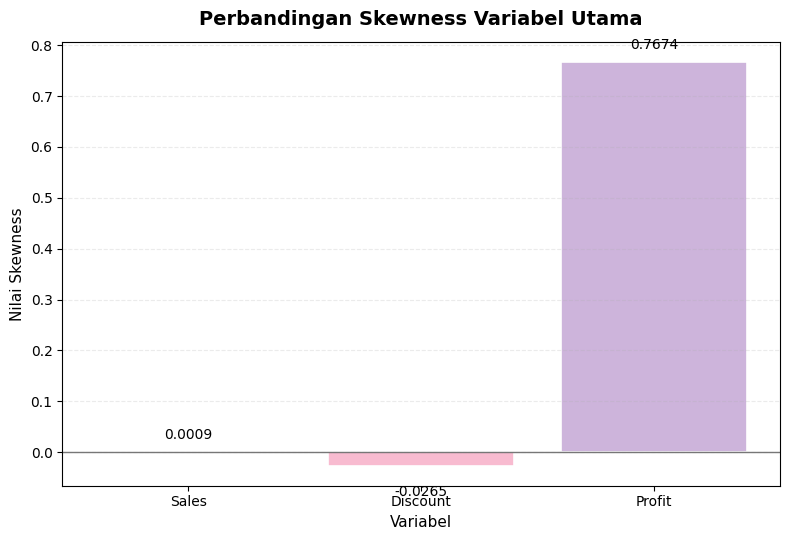

In [ ]:
warna_skew = [
    warna_sales,
    warna_discount,
    warna_profit
]

plt.figure(figsize=(8, 5.5))

bars = plt.bar(
    skewness_table["Variabel"],
    skewness_table["Skewness"],
    color=warna_skew,
    edgecolor="white",
    linewidth=1.2
)

plt.axhline(
    0,
    color="#777777",
    linewidth=1
)

plt.title(
    "Perbandingan Skewness Variabel Utama",
    fontweight="bold",
    pad=12
)

plt.xlabel("Variabel")
plt.ylabel("Nilai Skewness")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar, nilai in zip(
    bars,
    skewness_table["Skewness"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        nilai + (0.025 if nilai >= 0 else -0.06),
        f"{nilai:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "output_grafik/skewness_variabel_utama.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
perbandingan_distribusi = pd.DataFrame({
    "Mean": df[["Sales", "Discount", "Profit"]].mean(),
    "Median": df[["Sales", "Discount", "Profit"]].median(),
    "Skewness": df[["Sales", "Discount", "Profit"]].skew()
})

perbandingan_distribusi.round(4)

,Mean,Median,Skewness
Sales,"1,496.60","1,498.00",0.00
Discount,0.23,0.23,-0.03
Profit,374.94,320.78,0.77


### Ringkasan Analisis Distribusi

Berdasarkan histogram, boxplot, perbandingan mean dan median, serta nilai skewness, Sales dan Discount memiliki distribusi yang relatif simetris. Nilai skewness Sales sebesar 0,0009 dan Discount sebesar -0,0265 berada sangat dekat dengan nol.

Profit memiliki nilai skewness sebesar 0,7674 sehingga menunjukkan kemencengan positif atau ke arah kanan. Mean Profit yang lebih tinggi dibandingkan median serta keberadaan 43 potential outlier pada bagian atas distribusi mendukung karakteristik tersebut.

Meskipun Sales dan Discount memiliki skewness yang mendekati nol, hal tersebut tidak secara otomatis menunjukkan bahwa kedua variabel mengikuti distribusi normal.

Sales → 🩵 biru pastel

Discount → 🩷 pink pastel

Profit → 💜 ungu pastel

## 7. Analisis Hubungan Discount dengan Sales dan Profit

Analisis ini dilakukan untuk mengetahui arah dan kekuatan hubungan antara tingkat Discount dengan Sales serta antara Discount dengan Profit.

Pemeriksaan hubungan diawali dengan visualisasi data, kemudian dilanjutkan dengan perhitungan koefisien korelasi dan pengujian signifikansi statistik. Interpretasi difokuskan pada hubungan antarvariabel dan tidak digunakan untuk menyimpulkan hubungan sebab-akibat.

## A. Visualisasi Discount dengan Sales

Karena Discount hanya mempunyai 26 nilai berbeda, scatter plot biasa membentuk garis-garis vertikal. Itu bukan kesalahan data.
Supaya lebih mudah dibaca, kita tampilkan seluruh transaksi secara transparan dan ditambah garis rata-rata Sales pada setiap tingkat Discount.

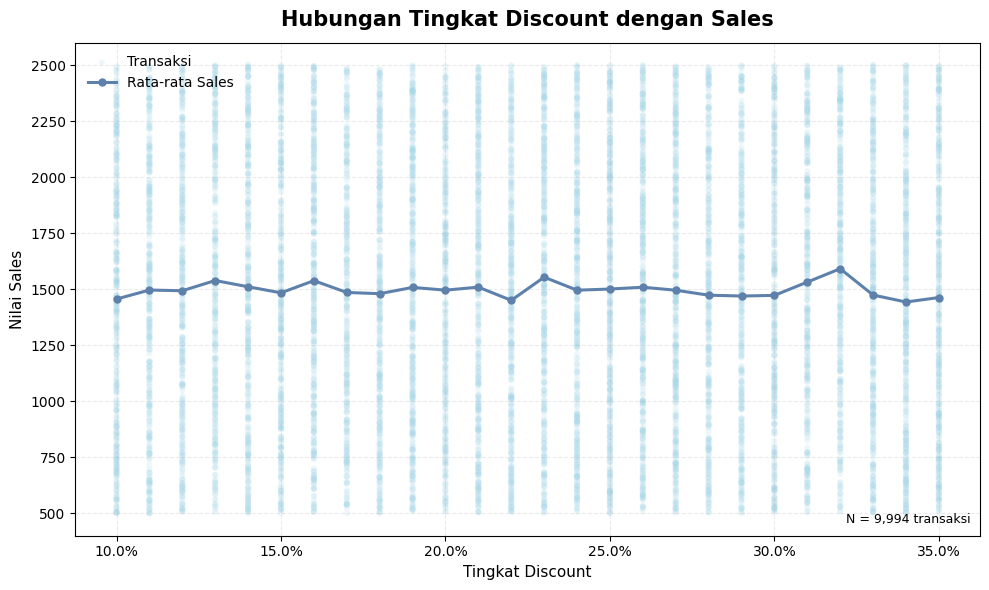

In [ ]:
mean_sales_discount = (
    df.groupby("Discount", as_index=False)["Sales"]
    .mean()
)

plt.figure(figsize=(10, 6))

# Seluruh transaksi
plt.scatter(
    df["Discount"],
    df["Sales"],
    color="#A8D8EA",
    alpha=0.18,
    s=20,
    edgecolors="none",
    label="Transaksi"
)

# Rata-rata Sales tiap tingkat Discount
plt.plot(
    mean_sales_discount["Discount"],
    mean_sales_discount["Sales"],
    color="#5E81AC",
    marker="o",
    markersize=5,
    linewidth=2.2,
    label="Rata-rata Sales"
)

plt.title(
    "Hubungan Tingkat Discount dengan Sales",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel("Tingkat Discount")
plt.ylabel("Nilai Sales")

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.grid(
    linestyle="--",
    alpha=0.25
)

plt.legend(frameon=False)

plt.text(
    0.99,
    0.02,
    f"N = {len(df):,} transaksi",
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "output_grafik/hubungan_discount_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## B. Visualisasi Discount dengan Profit

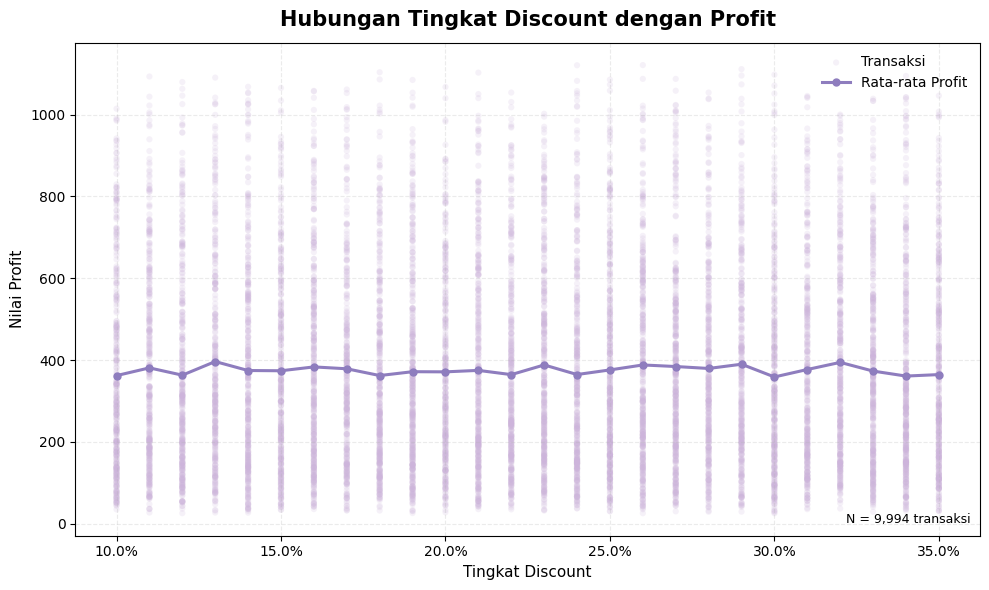

In [ ]:
mean_profit_discount = (
    df.groupby("Discount", as_index=False)["Profit"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    color="#CDB4DB",
    alpha=0.18,
    s=20,
    edgecolors="none",
    label="Transaksi"
)

plt.plot(
    mean_profit_discount["Discount"],
    mean_profit_discount["Profit"],
    color="#8E7DBE",
    marker="o",
    markersize=5,
    linewidth=2.2,
    label="Rata-rata Profit"
)

plt.title(
    "Hubungan Tingkat Discount dengan Profit",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel("Tingkat Discount")
plt.ylabel("Nilai Profit")

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.grid(
    linestyle="--",
    alpha=0.25
)

plt.legend(frameon=False)

plt.text(
    0.99,
    0.02,
    f"N = {len(df):,} transaksi",
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "output_grafik/hubungan_discount_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## C. Pearson atau Spearman?
Nah, bagian ini penting sekali secara metodologis.
Kondisi data kita:
- Discount hanya memiliki 26 tingkat nilai;
- Sales relatif simetris dan tidak memiliki potential outlier;
- Profit memiliki skewness 0,7674;
- Profit mempunyai 43 potential outlier;
- scatter plot tidak menunjukkan pola linear yang jelas.
Untuk analisis utama, kita gunakan:
Korelasi Spearman

Kenapa?
Spearman tidak mensyaratkan distribusi normal dan lebih tahan terhadap bentuk distribusi serta nilai ekstrem dibanding Pearson.
Supaya analisis lebih transparan, kita tetap menghitung Pearson sebagai pembanding, tetapi Spearman menjadi hasil utama yang kita interpretasikan.
Jadi jangan nanti berubah-ubah:
Analisis korelasi utama projek = Spearman.

In [ ]:
from scipy.stats import pearsonr, spearmanr

In [ ]:
# Discount dengan Sales
pearson_sales_r, pearson_sales_p = pearsonr(
    df["Discount"],
    df["Sales"]
)

spearman_sales_r, spearman_sales_p = spearmanr(
    df["Discount"],
    df["Sales"]
)

# Discount dengan Profit
pearson_profit_r, pearson_profit_p = pearsonr(
    df["Discount"],
    df["Profit"]
)

spearman_profit_r, spearman_profit_p = spearmanr(
    df["Discount"],
    df["Profit"]
)

In [ ]:
hasil_korelasi = pd.DataFrame({
    "Hubungan": [
        "Discount - Sales",
        "Discount - Profit"
    ],

    "Pearson r": [
        pearson_sales_r,
        pearson_profit_r
    ],

    "Pearson p-value": [
        pearson_sales_p,
        pearson_profit_p
    ],

    "Spearman rho": [
        spearman_sales_r,
        spearman_profit_r
    ],

    "Spearman p-value": [
        spearman_sales_p,
        spearman_profit_p
    ]
})

hasil_korelasi.round(4)

,Hubungan,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,Discount - Sales,-0.01,0.58,-0.01,0.57
1,Discount - Profit,0.00,1.00,0.00,0.63


In [ ]:
hasil_spearman = pd.DataFrame({
    "Hubungan": [
        "Discount dengan Sales",
        "Discount dengan Profit"
    ],

    "Spearman rho": [
        spearman_sales_r,
        spearman_profit_r
    ],

    "p-value": [
        spearman_sales_p,
        spearman_profit_p
    ]
})

hasil_spearman["Kesimpulan"] = [
    "Tidak signifikan",
    "Tidak signifikan"
]

hasil_spearman.round(4)

,Hubungan,Spearman rho,p-value,Kesimpulan
0,Discount dengan Sales,-0.01,0.57,Tidak signifikan
1,Discount dengan Profit,0.00,0.63,Tidak signifikan


### Hasil Analisis Hubungan

Berdasarkan korelasi Spearman, hubungan antara Discount dan Sales menghasilkan koefisien sebesar -0,0056 dengan p-value sebesar 0,5739. Koefisien yang sangat dekat dengan nol menunjukkan bahwa hubungan monotonic antara Discount dan Sales sangat lemah. Karena p-value lebih besar dari 0,05, tidak terdapat bukti statistik yang cukup untuk menunjukkan hubungan yang signifikan antara kedua variabel.

Hubungan antara Discount dan Profit menghasilkan koefisien Spearman sebesar 0,0048 dengan p-value sebesar 0,6314. Nilai koefisien tersebut juga sangat dekat dengan nol sehingga menunjukkan hubungan monotonic yang sangat lemah. Karena p-value lebih besar dari 0,05, tidak terdapat bukti statistik yang cukup untuk menunjukkan hubungan yang signifikan antara Discount dan Profit.

Hasil tersebut sejalan dengan scatter plot yang menunjukkan penyebaran Sales dan Profit yang luas pada berbagai tingkat Discount tanpa pola naik atau turun yang konsisten.

## 8. Analisis Berdasarkan Category

Analisis berdasarkan Category dilakukan untuk melihat karakteristik Sales, Discount, dan Profit pada masing-masing kategori produk serta mengevaluasi apakah pola hubungan Discount dengan Sales dan Profit berbeda antar kategori.

Category digunakan sebagai variabel pendukung atau pengelompokan, sedangkan variabel utama projek tetap terdiri atas Discount, Sales, dan Profit.

In [ ]:
warna_category = {
    "Bakery": "#FFD6A5",
    "Beverages": "#FFCAD4",
    "Eggs, Meat & Fish": "#BDE0FE",
    "Food Grains": "#CDEAC0",
    "Fruits & Veggies": "#D8B4E2",
    "Oil & Masala": "#FFF1A8",
    "Snacks": "#A9DEF9"
}

## 8. Analisis Berdasarkan Category

Analisis berdasarkan Category dilakukan untuk melihat karakteristik Sales, Discount, dan Profit pada masing-masing kategori produk serta mengevaluasi apakah pola hubungan Discount dengan Sales dan Profit berbeda antar kategori.

Category digunakan sebagai variabel pendukung atau pengelompokan, sedangkan variabel utama projek tetap terdiri atas Discount, Sales, dan Profit.

In [ ]:
warna_category = {
    "Bakery": "#FFD6A5",
    "Beverages": "#FFCAD4",
    "Eggs, Meat & Fish": "#BDE0FE",
    "Food Grains": "#CDEAC0",
    "Fruits & Veggies": "#D8B4E2",
    "Oil & Masala": "#FFF1A8",
    "Snacks": "#A9DEF9"
}

## A. Ringkasan statistik setiap kategori

In [ ]:
ringkasan_category = (
    df.groupby("Category")
    .agg(
        Jumlah_Transaksi=("Order ID", "count"),
        Mean_Sales=("Sales", "mean"),
        Median_Sales=("Sales", "median"),
        Mean_Discount=("Discount", "mean"),
        Median_Discount=("Discount", "median"),
        Mean_Profit=("Profit", "mean"),
        Median_Profit=("Profit", "median")
    )
    .reset_index()
)

ringkasan_category["Mean_Discount (%)"] = (
    ringkasan_category["Mean_Discount"] * 100
)

ringkasan_category["Median_Discount (%)"] = (
    ringkasan_category["Median_Discount"] * 100
)

ringkasan_category_tampil = ringkasan_category[
    [
        "Category",
        "Jumlah_Transaksi",
        "Mean_Sales",
        "Median_Sales",
        "Mean_Discount (%)",
        "Median_Discount (%)",
        "Mean_Profit",
        "Median_Profit"
    ]
]

ringkasan_category_tampil.round(2)

,Category,Jumlah_Transaksi,Mean_Sales,Median_Sales,Mean_Discount (%),Median_Discount (%),Mean_Profit,Median_Profit
0,Bakery,1413,"1,494.89","1,501.00",22.54,23.00,374.04,313.28
1,Beverages,1400,"1,489.51","1,512.00",23.03,23.00,375.43,326.63
2,"Eggs, Meat & Fish",1490,"1,521.75","1,522.00",22.78,23.00,380.78,331.50
3,Food Grains,1398,"1,513.07","1,541.50",22.85,23.00,378.51,318.30
4,Fruits & Veggies,1418,"1,481.47","1,450.00",22.93,23.00,374.05,327.51
5,Oil & Masala,1361,"1,497.75","1,495.00",22.45,23.00,365.83,309.12
6,Snacks,1514,"1,477.90","1,460.00",22.20,22.00,375.28,317.60


## B. Visualisasi rata-rata Sales berdasarkan Category

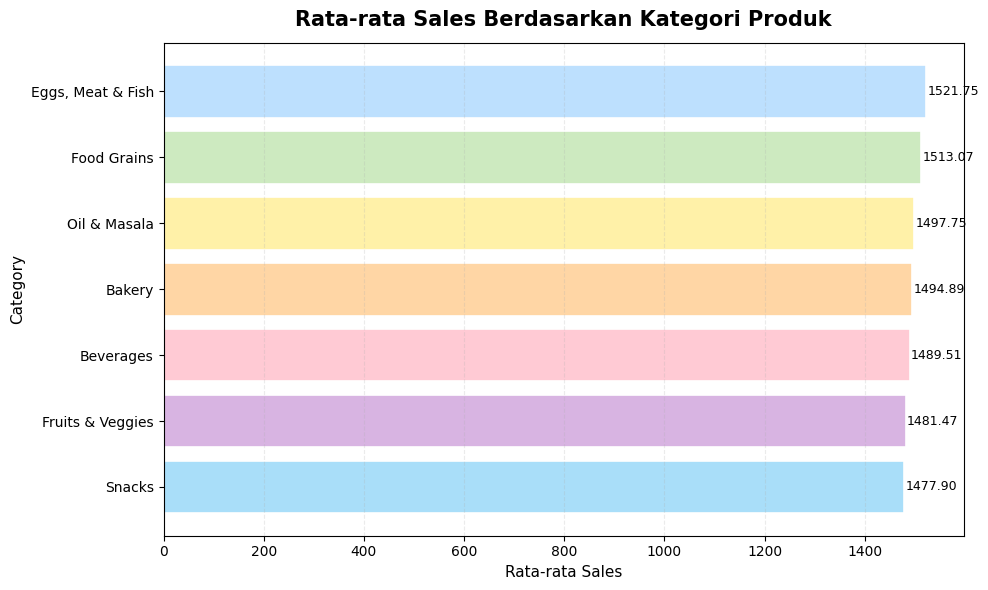

In [ ]:
plot_sales = (
    ringkasan_category
    .sort_values("Mean_Sales")
    .copy()
)

colors = [
    warna_category[kategori]
    for kategori in plot_sales["Category"]
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_sales["Category"],
    plot_sales["Mean_Sales"],
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Rata-rata Sales Berdasarkan Kategori Produk",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel("Rata-rata Sales")
plt.ylabel("Category")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

for bar, nilai in zip(
    bars,
    plot_sales["Mean_Sales"]
):
    plt.text(
        nilai + 3,
        bar.get_y() + bar.get_height()/2,
        f"{nilai:.2f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "output_grafik/mean_sales_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## C. Visualisasi rata-rata Profit berdasarkan Category

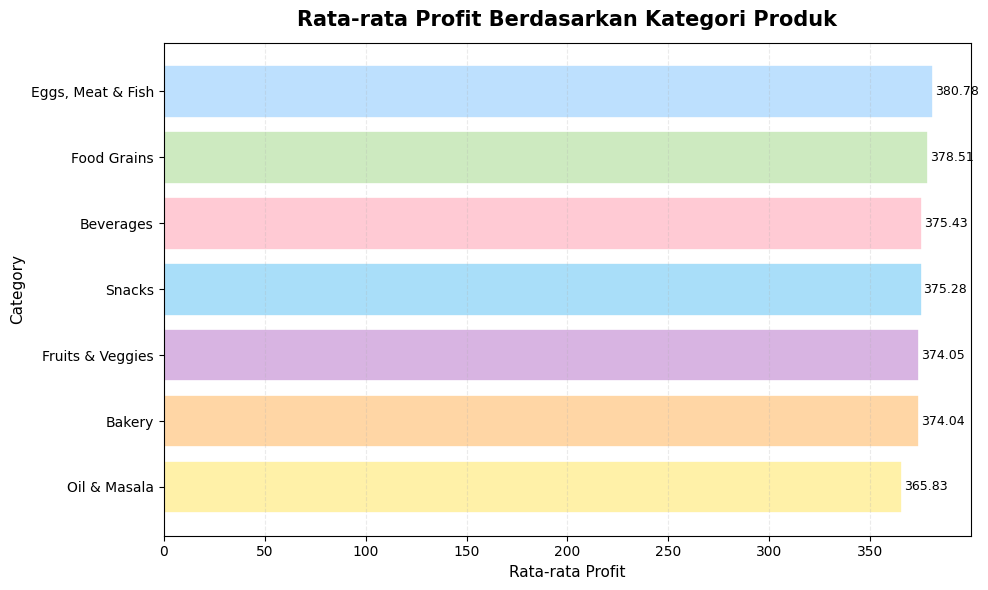

In [ ]:
plot_profit = (
    ringkasan_category
    .sort_values("Mean_Profit")
    .copy()
)

colors = [
    warna_category[kategori]
    for kategori in plot_profit["Category"]
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_profit["Category"],
    plot_profit["Mean_Profit"],
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Rata-rata Profit Berdasarkan Kategori Produk",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel("Rata-rata Profit")
plt.ylabel("Category")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

for bar, nilai in zip(
    bars,
    plot_profit["Mean_Profit"]
):
    plt.text(
        nilai + 1,
        bar.get_y() + bar.get_height()/2,
        f"{nilai:.2f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "output_grafik/mean_profit_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## D. Visualisasi rata-rata Discount berdasarkan Category

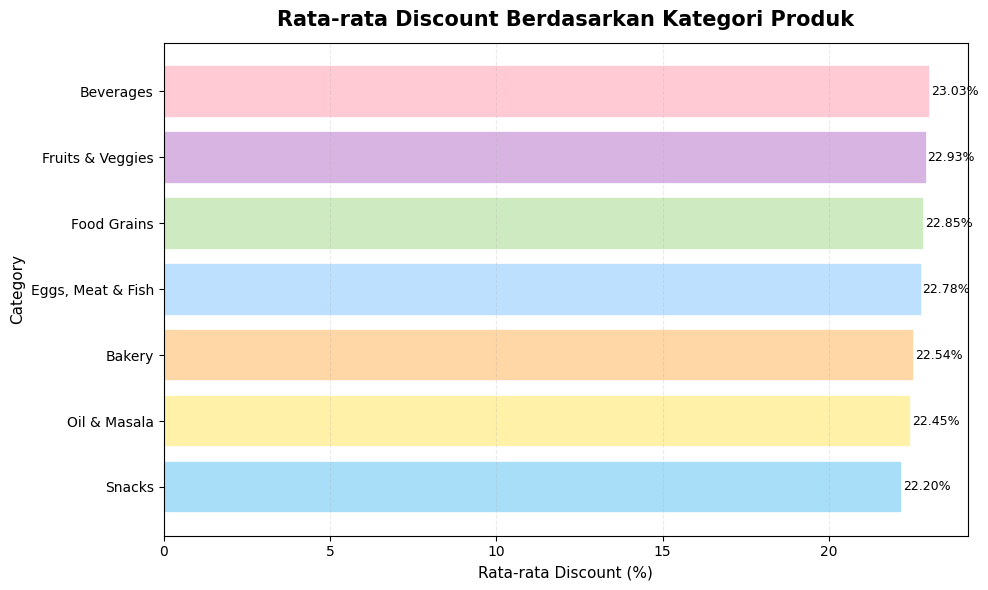

In [ ]:
plot_discount = (
    ringkasan_category
    .sort_values("Mean_Discount")
    .copy()
)

colors = [
    warna_category[kategori]
    for kategori in plot_discount["Category"]
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_discount["Category"],
    plot_discount["Mean_Discount"] * 100,
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Rata-rata Discount Berdasarkan Kategori Produk",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel("Rata-rata Discount (%)")
plt.ylabel("Category")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

for bar, nilai in zip(
    bars,
    plot_discount["Mean_Discount"] * 100
):
    plt.text(
        nilai + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"{nilai:.2f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "output_grafik/mean_discount_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## E. Hubungan Discount–Sales di tiap Category

In [ ]:
hasil_korelasi_category = []

for kategori in sorted(df["Category"].unique()):
    subset = df[df["Category"] == kategori]

    rho_sales, p_sales = spearmanr(
        subset["Discount"],
        subset["Sales"]
    )

    rho_profit, p_profit = spearmanr(
        subset["Discount"],
        subset["Profit"]
    )

    hasil_korelasi_category.append({
        "Category": kategori,
        "N": len(subset),
        "Rho Discount-Sales": rho_sales,
        "p-value Sales": p_sales,
        "Rho Discount-Profit": rho_profit,
        "p-value Profit": p_profit
    })

korelasi_category = pd.DataFrame(
    hasil_korelasi_category
)

korelasi_category.round(4)

,Category,N,Rho Discount-Sales,p-value Sales,Rho Discount-Profit,p-value Profit
0,Bakery,1413,-0.01,0.67,0.03,0.33
1,Beverages,1400,-0.01,0.58,0.01,0.76
2,"Eggs, Meat & Fish",1490,-0.01,0.74,-0.01,0.81
3,Food Grains,1398,0.01,0.85,0.04,0.16
4,Fruits & Veggies,1418,-0.02,0.53,-0.00,0.99
5,Oil & Masala,1361,0.02,0.46,0.01,0.83
6,Snacks,1514,-0.01,0.61,-0.04,0.13


## F. Kolom kesimpulan otomatis

In [ ]:
korelasi_category["Kesimpulan Sales"] = np.where(
    korelasi_category["p-value Sales"] < 0.05,
    "Signifikan",
    "Tidak signifikan"
)

korelasi_category["Kesimpulan Profit"] = np.where(
    korelasi_category["p-value Profit"] < 0.05,
    "Signifikan",
    "Tidak signifikan"
)

korelasi_category.round(4)

,Category,N,Rho Discount-Sales,p-value Sales,Rho Discount-Profit,p-value Profit,Kesimpulan Sales,Kesimpulan Profit
0,Bakery,1413,-0.01,0.67,0.03,0.33,Tidak signifikan,Tidak signifikan
1,Beverages,1400,-0.01,0.58,0.01,0.76,Tidak signifikan,Tidak signifikan
2,"Eggs, Meat & Fish",1490,-0.01,0.74,-0.01,0.81,Tidak signifikan,Tidak signifikan
3,Food Grains,1398,0.01,0.85,0.04,0.16,Tidak signifikan,Tidak signifikan
4,Fruits & Veggies,1418,-0.02,0.53,-0.00,0.99,Tidak signifikan,Tidak signifikan
5,Oil & Masala,1361,0.02,0.46,0.01,0.83,Tidak signifikan,Tidak signifikan
6,Snacks,1514,-0.01,0.61,-0.04,0.13,Tidak signifikan,Tidak signifikan


## G. Visualisasi koefisien Discount–Sales berdasarkan Category

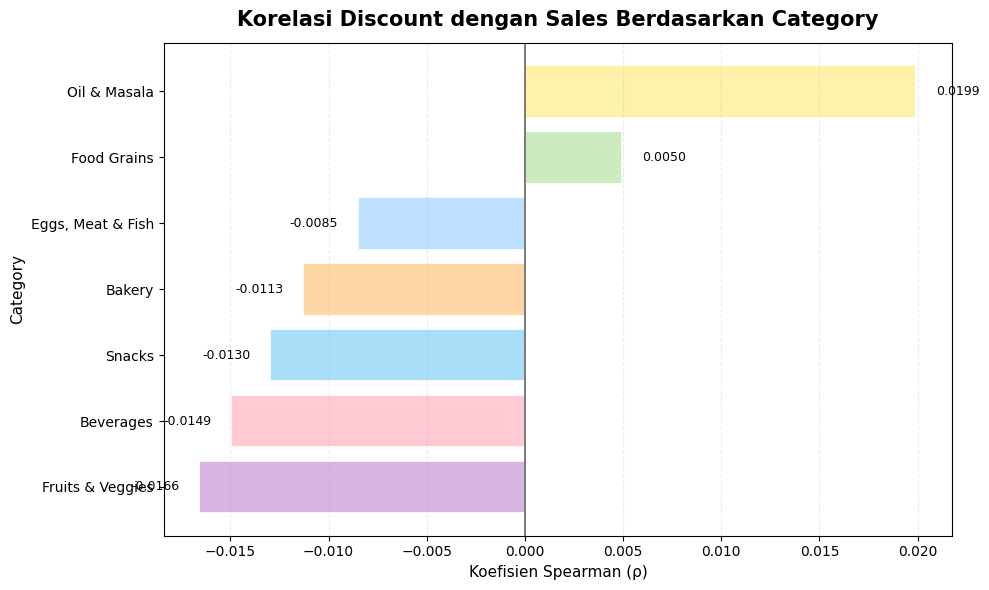

In [ ]:
plot_corr_sales = (
    korelasi_category
    .sort_values("Rho Discount-Sales")
    .copy()
)

colors = [
    warna_category[kategori]
    for kategori in plot_corr_sales["Category"]
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_corr_sales["Category"],
    plot_corr_sales["Rho Discount-Sales"],
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

plt.axvline(
    0,
    color="#666666",
    linewidth=1.2
)

plt.title(
    "Korelasi Discount dengan Sales Berdasarkan Category",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel("Koefisien Spearman (ρ)")
plt.ylabel("Category")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

for bar, nilai in zip(
    bars,
    plot_corr_sales["Rho Discount-Sales"]
):
    posisi = nilai + 0.001 if nilai >= 0 else nilai - 0.001

    plt.text(
        posisi,
        bar.get_y() + bar.get_height()/2,
        f"{nilai:.4f}",
        va="center",
        ha="left" if nilai >= 0 else "right",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "output_grafik/korelasi_discount_sales_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## H. Visualisasi koefisien Discount–Profit berdasarkan Category

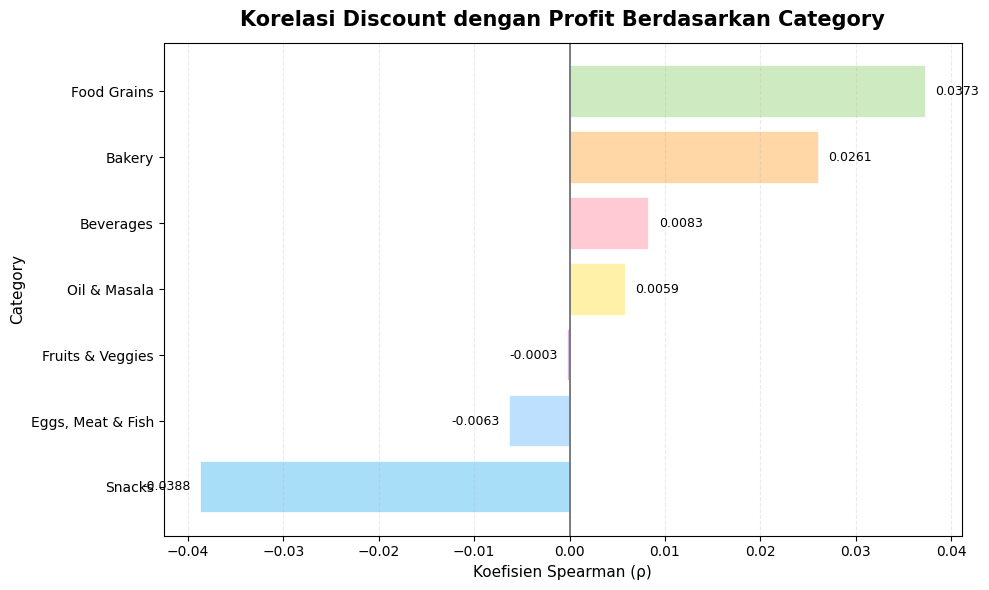

In [ ]:
plot_corr_profit = (
    korelasi_category
    .sort_values("Rho Discount-Profit")
    .copy()
)

colors = [
    warna_category[kategori]
    for kategori in plot_corr_profit["Category"]
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_corr_profit["Category"],
    plot_corr_profit["Rho Discount-Profit"],
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

plt.axvline(
    0,
    color="#666666",
    linewidth=1.2
)

plt.title(
    "Korelasi Discount dengan Profit Berdasarkan Category",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel("Koefisien Spearman (ρ)")
plt.ylabel("Category")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

for bar, nilai in zip(
    bars,
    plot_corr_profit["Rho Discount-Profit"]
):
    posisi = nilai + 0.001 if nilai >= 0 else nilai - 0.001

    plt.text(
        posisi,
        bar.get_y() + bar.get_height()/2,
        f"{nilai:.4f}",
        va="center",
        ha="left" if nilai >= 0 else "right",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "output_grafik/korelasi_discount_profit_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Hasil Analisis Berdasarkan Category

Secara deskriptif, terdapat perbedaan rata-rata Sales, Discount, dan Profit antar kategori produk. Kategori Eggs, Meat & Fish memiliki rata-rata Sales tertinggi sebesar 1.521,75 sekaligus rata-rata Profit tertinggi sebesar 380,78. Sementara itu, rata-rata Discount tertinggi terdapat pada kategori Beverages sebesar 23,03%.

Meskipun terdapat variasi nilai rata-rata antar kategori, analisis korelasi Spearman menunjukkan bahwa hubungan Discount dengan Sales tetap sangat lemah pada seluruh kategori produk. Koefisien korelasi berada sangat dekat dengan nol dan seluruh p-value lebih besar dari 0,05.

Pola yang sama ditemukan pada hubungan Discount dengan Profit. Seluruh kategori menghasilkan koefisien Spearman yang sangat dekat dengan nol dan tidak terdapat hubungan yang signifikan secara statistik pada taraf signifikansi 5%.

Dengan demikian, pemisahan transaksi berdasarkan Category tidak menunjukkan adanya pola hubungan Discount dengan Sales maupun Profit yang secara konsisten lebih kuat dibandingkan hasil analisis keseluruhan.

## 9. Analisis Probabilitas Bersyarat

Analisis probabilitas dilakukan untuk menghitung peluang empiris suatu transaksi memiliki Profit tinggi berdasarkan tingkat Discount dan Category.

Profit tinggi didefinisikan menggunakan kuartil ketiga (Q3), yaitu transaksi dengan nilai Profit sama dengan atau lebih besar dari Q3. Pendekatan ini digunakan agar batas Profit tinggi ditentukan berdasarkan distribusi data dan bukan berdasarkan nilai yang ditetapkan secara subjektif.

Tingkat Discount dikelompokkan menjadi tiga kategori, yaitu rendah, sedang, dan tinggi, menggunakan pembagian tertil agar jumlah observasi pada setiap kelompok relatif seimbang.

## A. Menentukan batas Profit tinggi

In [ ]:
q3_profit = df["Profit"].quantile(0.75)

print(f"Q3 Profit              : {q3_profit:.4f}")
print(f"Batas Profit tinggi    : Profit >= {q3_profit:.2f}")

Q3 Profit              : 525.6275
Batas Profit tinggi    : Profit >= 525.63


## B. Membuat indikator Profit tinggi

In [ ]:
df["Profit_Tinggi"] = df["Profit"] >= q3_profit

print(
    df["Profit_Tinggi"]
    .value_counts()
)

Profit_Tinggi
False    7495
True     2499
Name: count, dtype: int64


In [ ]:
prob_profit_tinggi = df["Profit_Tinggi"].mean()

print(
    f"Probabilitas Profit tinggi secara keseluruhan: "
    f"{prob_profit_tinggi:.2%}"
)

Probabilitas Profit tinggi secara keseluruhan: 25.01%


## C. Membuat kelompok tingkat Discount

In [ ]:
df["Tingkat_Discount"], batas_discount = pd.qcut(
    df["Discount"],
    q=3,
    labels=[
        "Rendah",
        "Sedang",
        "Tinggi"
    ],
    retbins=True
)

print("Batas pembagian Discount:")
print(batas_discount)

print("\nJumlah transaksi per kelompok:")
print(
    df["Tingkat_Discount"]
    .value_counts()
    .sort_index()
)

Batas pembagian Discount:
[0.1  0.19 0.27 0.35]

Jumlah transaksi per kelompok:
Tingkat_Discount
Rendah    3736
Sedang    3184
Tinggi    3074
Name: count, dtype: int64


## D. Formula probabilitas bersyarat

### Probabilitas Bersyarat

Probabilitas bersyarat dihitung menggunakan rumus:

P(A | B) = P(A ∩ B) / P(B)

Dalam projek ini:

P(Profit Tinggi | Tingkat Discount, Category)

dihitung sebagai jumlah transaksi Profit tinggi pada kombinasi tingkat Discount dan Category tertentu dibagi dengan seluruh transaksi pada kombinasi yang sama.

## E. Probabilitas Profit tinggi berdasarkan tingkat Discount

In [ ]:
prob_discount = (
    df.groupby(
        "Tingkat_Discount",
        observed=True
    )["Profit_Tinggi"]
    .agg(
        Jumlah_Transaksi="count",
        Profit_Tinggi="sum",
        Probabilitas="mean"
    )
    .reset_index()
)

prob_discount["Probabilitas (%)"] = (
    prob_discount["Probabilitas"] * 100
)

prob_discount.round(2)

,Tingkat_Discount,Jumlah_Transaksi,Profit_Tinggi,Probabilitas,Probabilitas (%)
0,Rendah,3736,933,0.25,24.97
1,Sedang,3184,805,0.25,25.28
2,Tinggi,3074,761,0.25,24.76


## F. Visualisasi probabilitas berdasarkan Discount

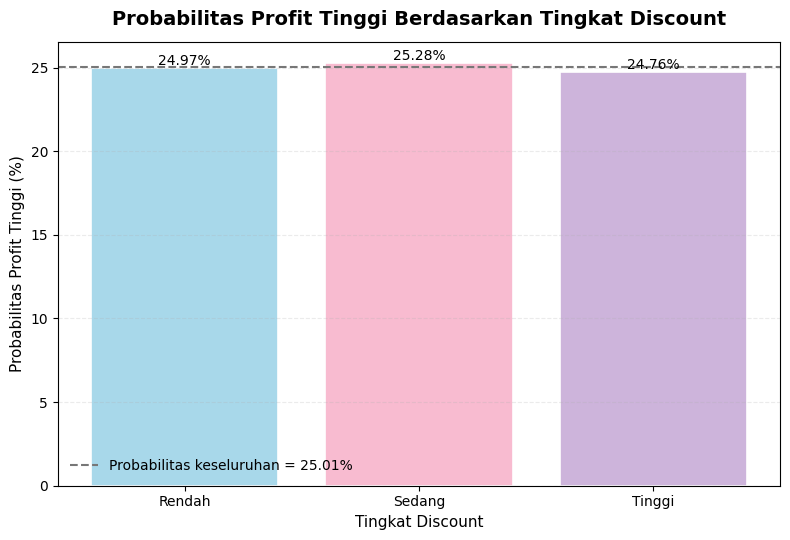

In [ ]:
warna_tingkat_discount = [
    "#A8D8EA",   # rendah
    "#F8BBD0",   # sedang
    "#CDB4DB"    # tinggi
]

plt.figure(figsize=(8, 5.5))

bars = plt.bar(
    prob_discount["Tingkat_Discount"].astype(str),
    prob_discount["Probabilitas (%)"],
    color=warna_tingkat_discount,
    edgecolor="white",
    linewidth=1.2
)

plt.axhline(
    prob_profit_tinggi * 100,
    color="#777777",
    linestyle="--",
    linewidth=1.5,
    label=f"Probabilitas keseluruhan = {prob_profit_tinggi:.2%}"
)

plt.title(
    "Probabilitas Profit Tinggi Berdasarkan Tingkat Discount",
    fontweight="bold",
    pad=12
)

plt.xlabel("Tingkat Discount")
plt.ylabel("Probabilitas Profit Tinggi (%)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar, nilai in zip(
    bars,
    prob_discount["Probabilitas (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        nilai + 0.15,
        f"{nilai:.2f}%",
        ha="center",
        fontsize=10
    )

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "output_grafik/probabilitas_profit_tinggi_discount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## G. Probabilitas Profit tinggi berdasarkan Category

In [ ]:
prob_category = (
    df.groupby("Category")["Profit_Tinggi"]
    .agg(
        Jumlah_Transaksi="count",
        Profit_Tinggi="sum",
        Probabilitas="mean"
    )
    .reset_index()
)

prob_category["Probabilitas (%)"] = (
    prob_category["Probabilitas"] * 100
)

prob_category.round(2)

,Category,Jumlah_Transaksi,Profit_Tinggi,Probabilitas,Probabilitas (%)
0,Bakery,1413,350,0.25,24.77
1,Beverages,1400,363,0.26,25.93
2,"Eggs, Meat & Fish",1490,399,0.27,26.78
3,Food Grains,1398,363,0.26,25.97
4,Fruits & Veggies,1418,336,0.24,23.70
5,Oil & Masala,1361,328,0.24,24.10
6,Snacks,1514,360,0.24,23.78


## H. Kondisi utama: Discount DAN Category sekaligus

In [ ]:
prob_conditional = (
    df.groupby(
        ["Category", "Tingkat_Discount"],
        observed=True
    )["Profit_Tinggi"]
    .agg(
        Jumlah_Transaksi="count",
        Profit_Tinggi="sum",
        Probabilitas="mean"
    )
    .reset_index()
)

prob_conditional["Probabilitas (%)"] = (
    prob_conditional["Probabilitas"] * 100
)

prob_conditional[
    [
        "Category",
        "Tingkat_Discount",
        "Jumlah_Transaksi",
        "Profit_Tinggi",
        "Probabilitas (%)"
    ]
].round(2)

,Category,Tingkat_Discount,Jumlah_Transaksi,Profit_Tinggi,Probabilitas (%)
0,Bakery,Rendah,519,114,21.97
1,Bakery,Sedang,493,130,26.37
2,Bakery,Tinggi,401,106,26.43
3,Beverages,Rendah,506,128,25.30
4,Beverages,Sedang,431,116,26.91
5,Beverages,Tinggi,463,119,25.70
6,"Eggs, Meat & Fish",Rendah,542,156,28.78
7,"Eggs, Meat & Fish",Sedang,498,132,26.51
8,"Eggs, Meat & Fish",Tinggi,450,111,24.67
9,Food Grains,Rendah,521,129,24.76


## I. Buat tabel pivot

In [ ]:
tabel_probabilitas = (
    prob_conditional
    .pivot(
        index="Category",
        columns="Tingkat_Discount",
        values="Probabilitas (%)"
    )
    .reindex(
        columns=[
            "Rendah",
            "Sedang",
            "Tinggi"
        ]
    )
)

tabel_probabilitas.round(2)

Tingkat_Discount,Rendah,Sedang,Tinggi
Category,,,
Bakery,21.97,26.37,26.43
Beverages,25.30,26.91,25.70
"Eggs, Meat & Fish",28.78,26.51,24.67
Food Grains,24.76,26.81,26.56
Fruits & Veggies,23.12,25.06,23.14
Oil & Masala,24.18,22.22,26.07
Snacks,26.39,23.06,21.04


## J. Visualisasi grouped bar

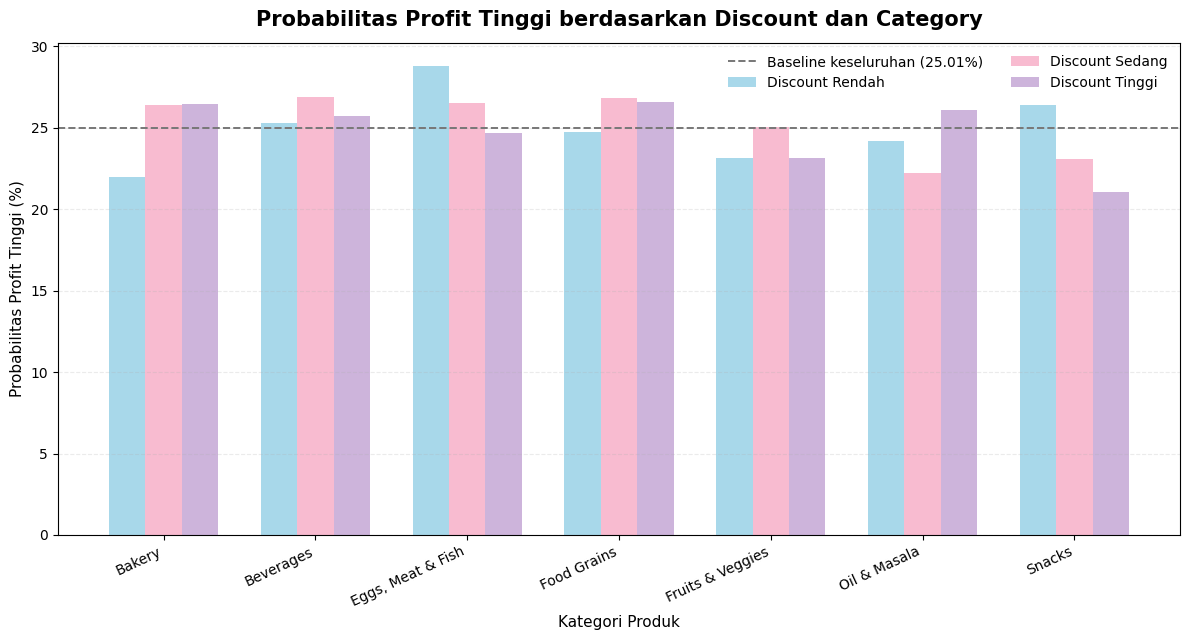

In [ ]:
kategori = tabel_probabilitas.index
x = np.arange(len(kategori))
width = 0.24

plt.figure(figsize=(12, 6.5))

plt.bar(
    x - width,
    tabel_probabilitas["Rendah"],
    width,
    label="Discount Rendah",
    color="#A8D8EA"
)

plt.bar(
    x,
    tabel_probabilitas["Sedang"],
    width,
    label="Discount Sedang",
    color="#F8BBD0"
)

plt.bar(
    x + width,
    tabel_probabilitas["Tinggi"],
    width,
    label="Discount Tinggi",
    color="#CDB4DB"
)

plt.axhline(
    prob_profit_tinggi * 100,
    linestyle="--",
    linewidth=1.4,
    color="#777777",
    label=f"Baseline keseluruhan ({prob_profit_tinggi:.2%})"
)

plt.title(
    "Probabilitas Profit Tinggi berdasarkan Discount dan Category",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel("Kategori Produk")
plt.ylabel("Probabilitas Profit Tinggi (%)")

plt.xticks(
    x,
    kategori,
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.legend(
    frameon=False,
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "output_grafik/probabilitas_profit_tinggi_category_discount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

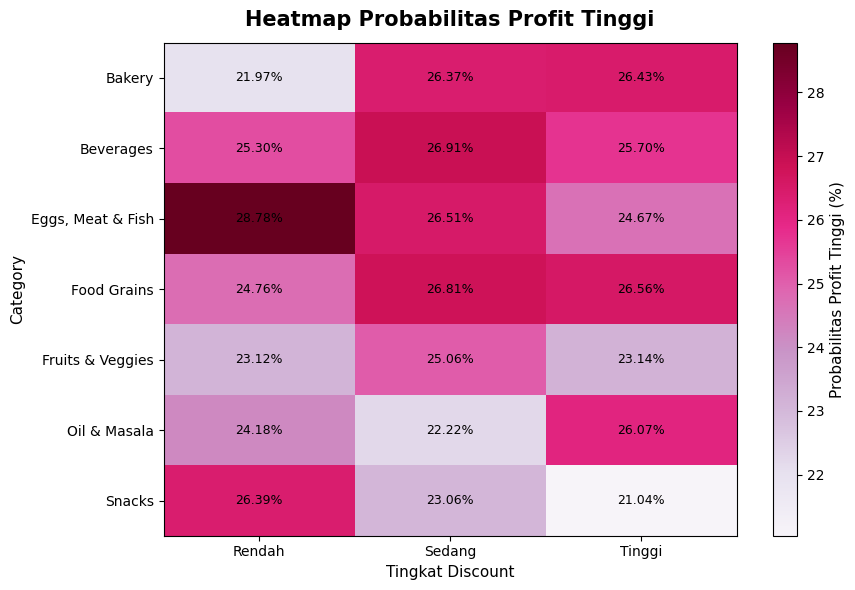

In [ ]:
plt.figure(figsize=(9, 6))

matrix_prob = tabel_probabilitas.values

gambar = plt.imshow(
    matrix_prob,
    cmap="PuRd",
    aspect="auto"
)

plt.colorbar(
    gambar,
    label="Probabilitas Profit Tinggi (%)"
)

plt.xticks(
    range(len(tabel_probabilitas.columns)),
    tabel_probabilitas.columns
)

plt.yticks(
    range(len(tabel_probabilitas.index)),
    tabel_probabilitas.index
)

plt.xlabel("Tingkat Discount")
plt.ylabel("Category")

plt.title(
    "Heatmap Probabilitas Profit Tinggi",
    fontsize=15,
    fontweight="bold",
    pad=12
)

for i in range(len(tabel_probabilitas.index)):
    for j in range(len(tabel_probabilitas.columns)):
        plt.text(
            j,
            i,
            f"{matrix_prob[i, j]:.2f}%",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "output_grafik/heatmap_probabilitas_profit_tinggi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## M. Probabilitas tertinggi dan terendah

In [ ]:
tertinggi = prob_conditional.loc[
    prob_conditional["Probabilitas"].idxmax()
]

terendah = prob_conditional.loc[
    prob_conditional["Probabilitas"].idxmin()
]

print("=== PROBABILITAS TERTINGGI ===")
print("Category :", tertinggi["Category"])
print("Discount :", tertinggi["Tingkat_Discount"])
print(
    f"Probabilitas : "
    f"{tertinggi['Probabilitas']:.2%}"
)

print("\n=== PROBABILITAS TERENDAH ===")
print("Category :", terendah["Category"])
print("Discount :", terendah["Tingkat_Discount"])
print(
    f"Probabilitas : "
    f"{terendah['Probabilitas']:.2%}"
)

=== PROBABILITAS TERTINGGI ===
Category : Eggs, Meat & Fish
Discount : Rendah
Probabilitas : 28.78%

=== PROBABILITAS TERENDAH ===
Category : Snacks
Discount : Tinggi
Probabilitas : 21.04%


### Hasil Analisis Probabilitas Bersyarat

Profit tinggi didefinisikan sebagai nilai Profit yang sama dengan atau lebih besar dari kuartil ketiga (Q3), yaitu 525,63. Berdasarkan definisi tersebut, terdapat 2.499 transaksi Profit tinggi dari total 9.994 transaksi, sehingga probabilitas empiris Profit tinggi secara keseluruhan adalah sekitar 25,01%.

Berdasarkan tingkat Discount, probabilitas Profit tinggi pada kelompok Discount rendah sebesar 24,97%, kelompok sedang sebesar 25,28%, dan kelompok tinggi sebesar 24,76%. Nilai tersebut relatif berdekatan dan tidak menunjukkan pola peningkatan probabilitas Profit tinggi yang konsisten seiring meningkatnya tingkat Discount.

Ketika dianalisis berdasarkan kombinasi Category dan tingkat Discount, probabilitas Profit tinggi tertinggi terdapat pada kategori Eggs, Meat & Fish dengan Discount rendah sebesar 28,78%. Sementara itu, probabilitas terendah terdapat pada kategori Snacks dengan Discount tinggi sebesar 21,04%.

Secara deskriptif, probabilitas Profit tinggi bervariasi antar kombinasi Category dan tingkat Discount. Namun, tidak terlihat pola yang konsisten bahwa tingkat Discount yang lebih tinggi selalu berkaitan dengan probabilitas Profit tinggi yang lebih besar.

Probabilitas yang dihitung merupakan probabilitas empiris berdasarkan frekuensi transaksi pada dataset dan tidak dimaksudkan sebagai jaminan probabilitas untuk seluruh transaksi retail di luar dataset yang dianalisis.

## 10. Ringkasan Hasil Analisis dan Kesimpulan Statistik

Bagian ini merangkum hasil utama analisis statistik dan probabilitas berdasarkan tiga rumusan masalah projek.

Ringkasan disusun berdasarkan hasil statistik deskriptif, analisis distribusi, korelasi Spearman, analisis berdasarkan Category, serta probabilitas bersyarat.

In [ ]:
from scipy.stats import spearmanr

# =========================
# STATISTIK DESKRIPTIF
# =========================

mean_sales = df["Sales"].mean()
median_sales = df["Sales"].median()
skew_sales = df["Sales"].skew()

mean_discount = df["Discount"].mean()
median_discount = df["Discount"].median()
skew_discount = df["Discount"].skew()

mean_profit = df["Profit"].mean()
median_profit = df["Profit"].median()
skew_profit = df["Profit"].skew()


# =========================
# KORELASI SPEARMAN
# =========================

rho_sales, p_sales = spearmanr(
    df["Discount"],
    df["Sales"]
)

rho_profit, p_profit = spearmanr(
    df["Discount"],
    df["Profit"]
)


# =========================
# PROFIT TINGGI
# =========================

q3_profit = df["Profit"].quantile(0.75)

df["Profit_Tinggi"] = (
    df["Profit"] >= q3_profit
)

prob_profit_tinggi = (
    df["Profit_Tinggi"].mean()
)


# =========================
# KELOMPOK DISCOUNT
# =========================

df["Tingkat_Discount"] = pd.qcut(
    df["Discount"],
    q=3,
    labels=["Rendah", "Sedang", "Tinggi"]
)

prob_discount = (
    df.groupby(
        "Tingkat_Discount",
        observed=True
    )["Profit_Tinggi"]
    .mean()
)


# =========================
# RINGKASAN CATEGORY
# =========================

summary_category = (
    df.groupby("Category")
    .agg(
        Mean_Sales=("Sales", "mean"),
        Mean_Discount=("Discount", "mean"),
        Mean_Profit=("Profit", "mean")
    )
)

sales_category_max = (
    summary_category["Mean_Sales"].idxmax()
)

profit_category_max = (
    summary_category["Mean_Profit"].idxmax()
)


# =========================
# PROBABILITAS KONDISIONAL
# =========================

prob_conditional = (
    df.groupby(
        ["Category", "Tingkat_Discount"],
        observed=True
    )["Profit_Tinggi"]
    .mean()
    .reset_index(name="Probabilitas")
)

kombinasi_max = prob_conditional.loc[
    prob_conditional["Probabilitas"].idxmax()
]

kombinasi_min = prob_conditional.loc[
    prob_conditional["Probabilitas"].idxmin()
]

In [ ]:
ringkasan_hasil = pd.DataFrame({
    "Aspek Analisis": [
        "Jumlah data",
        "Distribusi Sales",
        "Distribusi Discount",
        "Distribusi Profit",
        "Hubungan Discount-Sales",
        "Hubungan Discount-Profit",
        "Mean Sales tertinggi berdasarkan Category",
        "Mean Profit tertinggi berdasarkan Category",
        "Probabilitas Profit tinggi keseluruhan",
        "Probabilitas berdasarkan Discount",
        "Kombinasi probabilitas tertinggi",
        "Kombinasi probabilitas terendah"
    ],

    "Hasil": [
        f"{len(df):,} transaksi, 11 variabel",

        (
            f"Mean = {mean_sales:.2f}; "
            f"Median = {median_sales:.2f}; "
            f"Skewness = {skew_sales:.4f}"
        ),

        (
            f"Mean = {mean_discount:.2%}; "
            f"Median = {median_discount:.2%}; "
            f"Skewness = {skew_discount:.4f}"
        ),

        (
            f"Mean = {mean_profit:.2f}; "
            f"Median = {median_profit:.2f}; "
            f"Skewness = {skew_profit:.4f}"
        ),

        (
            f"Spearman rho = {rho_sales:.4f}; "
            f"p-value = {p_sales:.4f}"
        ),

        (
            f"Spearman rho = {rho_profit:.4f}; "
            f"p-value = {p_profit:.4f}"
        ),

        (
            f"{sales_category_max} "
            f"({summary_category.loc[sales_category_max, 'Mean_Sales']:.2f})"
        ),

        (
            f"{profit_category_max} "
            f"({summary_category.loc[profit_category_max, 'Mean_Profit']:.2f})"
        ),

        f"{prob_profit_tinggi:.2%}",

        (
            f"Rendah = {prob_discount['Rendah']:.2%}; "
            f"Sedang = {prob_discount['Sedang']:.2%}; "
            f"Tinggi = {prob_discount['Tinggi']:.2%}"
        ),

        (
            f"{kombinasi_max['Category']} - "
            f"{kombinasi_max['Tingkat_Discount']} "
            f"({kombinasi_max['Probabilitas']:.2%})"
        ),

        (
            f"{kombinasi_min['Category']} - "
            f"{kombinasi_min['Tingkat_Discount']} "
            f"({kombinasi_min['Probabilitas']:.2%})"
        )
    ]
})

ringkasan_hasil

,Aspek Analisis,Hasil
0,Jumlah data,"9,994 transaksi, 11 variabel"
1,Distribusi Sales,Mean = 1496.60; Median = 1498.00; Skewness = 0...
2,Distribusi Discount,Mean = 22.68%; Median = 23.00%; Skewness = -0....
3,Distribusi Profit,Mean = 374.94; Median = 320.78; Skewness = 0.7674
4,Hubungan Discount-Sales,Spearman rho = -0.0056; p-value = 0.5739
5,Hubungan Discount-Profit,Spearman rho = 0.0048; p-value = 0.6314
6,Mean Sales tertinggi berdasarkan Category,"Eggs, Meat & Fish (1521.75)"
7,Mean Profit tertinggi berdasarkan Category,"Eggs, Meat & Fish (380.78)"
8,Probabilitas Profit tinggi keseluruhan,25.01%
9,Probabilitas berdasarkan Discount,Rendah = 24.97%; Sedang = 25.28%; Tinggi = 24.76%


In [ ]:
jawaban_rumusan_masalah = pd.DataFrame({
    "Rumusan Masalah": [
        "RM 1",
        "RM 2",
        "RM 3"
    ],

    "Fokus": [
        "Karakteristik Sales, Discount, dan Profit berdasarkan Category",

        "Hubungan Discount dengan Sales dan Profit",

        "Probabilitas Profit tinggi berdasarkan tingkat Discount dan Category"
    ],

    "Ringkasan Hasil": [
        (
            "Sales dan Discount relatif simetris, sedangkan Profit "
            "memiliki kemencengan positif. Secara deskriptif terdapat "
            "variasi nilai antar Category."
        ),

        (
            f"Discount-Sales: rho = {rho_sales:.4f}, "
            f"p = {p_sales:.4f}; "
            f"Discount-Profit: rho = {rho_profit:.4f}, "
            f"p = {p_profit:.4f}. "
            "Kedua hubungan sangat lemah dan tidak signifikan."
        ),

        (
            f"Probabilitas Profit tinggi keseluruhan = "
            f"{prob_profit_tinggi:.2%}. "
            f"Kombinasi tertinggi terdapat pada "
            f"{kombinasi_max['Category']} dengan Discount "
            f"{kombinasi_max['Tingkat_Discount']} "
            f"sebesar {kombinasi_max['Probabilitas']:.2%}."
        )
    ]
})

jawaban_rumusan_masalah

,Rumusan Masalah,Fokus,Ringkasan Hasil
0,RM 1,"Karakteristik Sales, Discount, dan Profit berd...","Sales dan Discount relatif simetris, sedangkan..."
1,RM 2,Hubungan Discount dengan Sales dan Profit,"Discount-Sales: rho = -0.0056, p = 0.5739; Dis..."
2,RM 3,Probabilitas Profit tinggi berdasarkan tingkat...,Probabilitas Profit tinggi keseluruhan = 25.01...


### Kesimpulan Statistik

Berdasarkan analisis terhadap 9.994 transaksi, Sales memiliki rata-rata sebesar 1.496,60 dan distribusi yang relatif simetris. Discount memiliki rata-rata sebesar 22,68% dengan distribusi yang juga relatif simetris. Sementara itu, Profit memiliki rata-rata sebesar 374,94 dan menunjukkan kemencengan positif dengan nilai skewness sebesar 0,7674.

Secara deskriptif terdapat variasi nilai Sales, Discount, dan Profit antar kategori produk. Kategori Eggs, Meat & Fish memiliki rata-rata Sales dan Profit tertinggi, sedangkan rata-rata Discount tertinggi terdapat pada kategori Beverages.

Analisis korelasi Spearman menunjukkan bahwa hubungan Discount dengan Sales sangat lemah dan tidak signifikan secara statistik (rho = -0,0056; p = 0,5739). Hubungan Discount dengan Profit juga sangat lemah dan tidak signifikan (rho = 0,0048; p = 0,6314). Pola tersebut tetap konsisten ketika analisis dilakukan secara terpisah berdasarkan Category.

Profit tinggi didefinisikan sebagai Profit yang sama dengan atau lebih besar dari Q3, yaitu 525,63. Probabilitas Profit tinggi secara keseluruhan sebesar 25,01%. Berdasarkan tingkat Discount, probabilitas Profit tinggi masing-masing sebesar 24,97% pada Discount rendah, 25,28% pada Discount sedang, dan 24,76% pada Discount tinggi.

Kombinasi Category dan tingkat Discount dengan probabilitas Profit tinggi terbesar terdapat pada Eggs, Meat & Fish dengan Discount rendah sebesar 28,78%, sedangkan probabilitas terendah terdapat pada Snacks dengan Discount tinggi sebesar 21,04%.

Secara keseluruhan, hasil analisis tidak menunjukkan pola yang konsisten bahwa tingkat Discount yang lebih tinggi berkaitan dengan Sales, Profit, maupun probabilitas Profit tinggi yang lebih besar pada dataset yang dianalisis.

In [ ]:
import os

os.makedirs(
    "output_tabel",
    exist_ok=True
)

ringkasan_hasil.to_excel(
    "output_tabel/ringkasan_hasil_analisis.xlsx",
    index=False
)

jawaban_rumusan_masalah.to_excel(
    "output_tabel/jawaban_rumusan_masalah.xlsx",
    index=False
)

print("Tabel hasil berhasil disimpan.")

Tabel hasil berhasil disimpan.


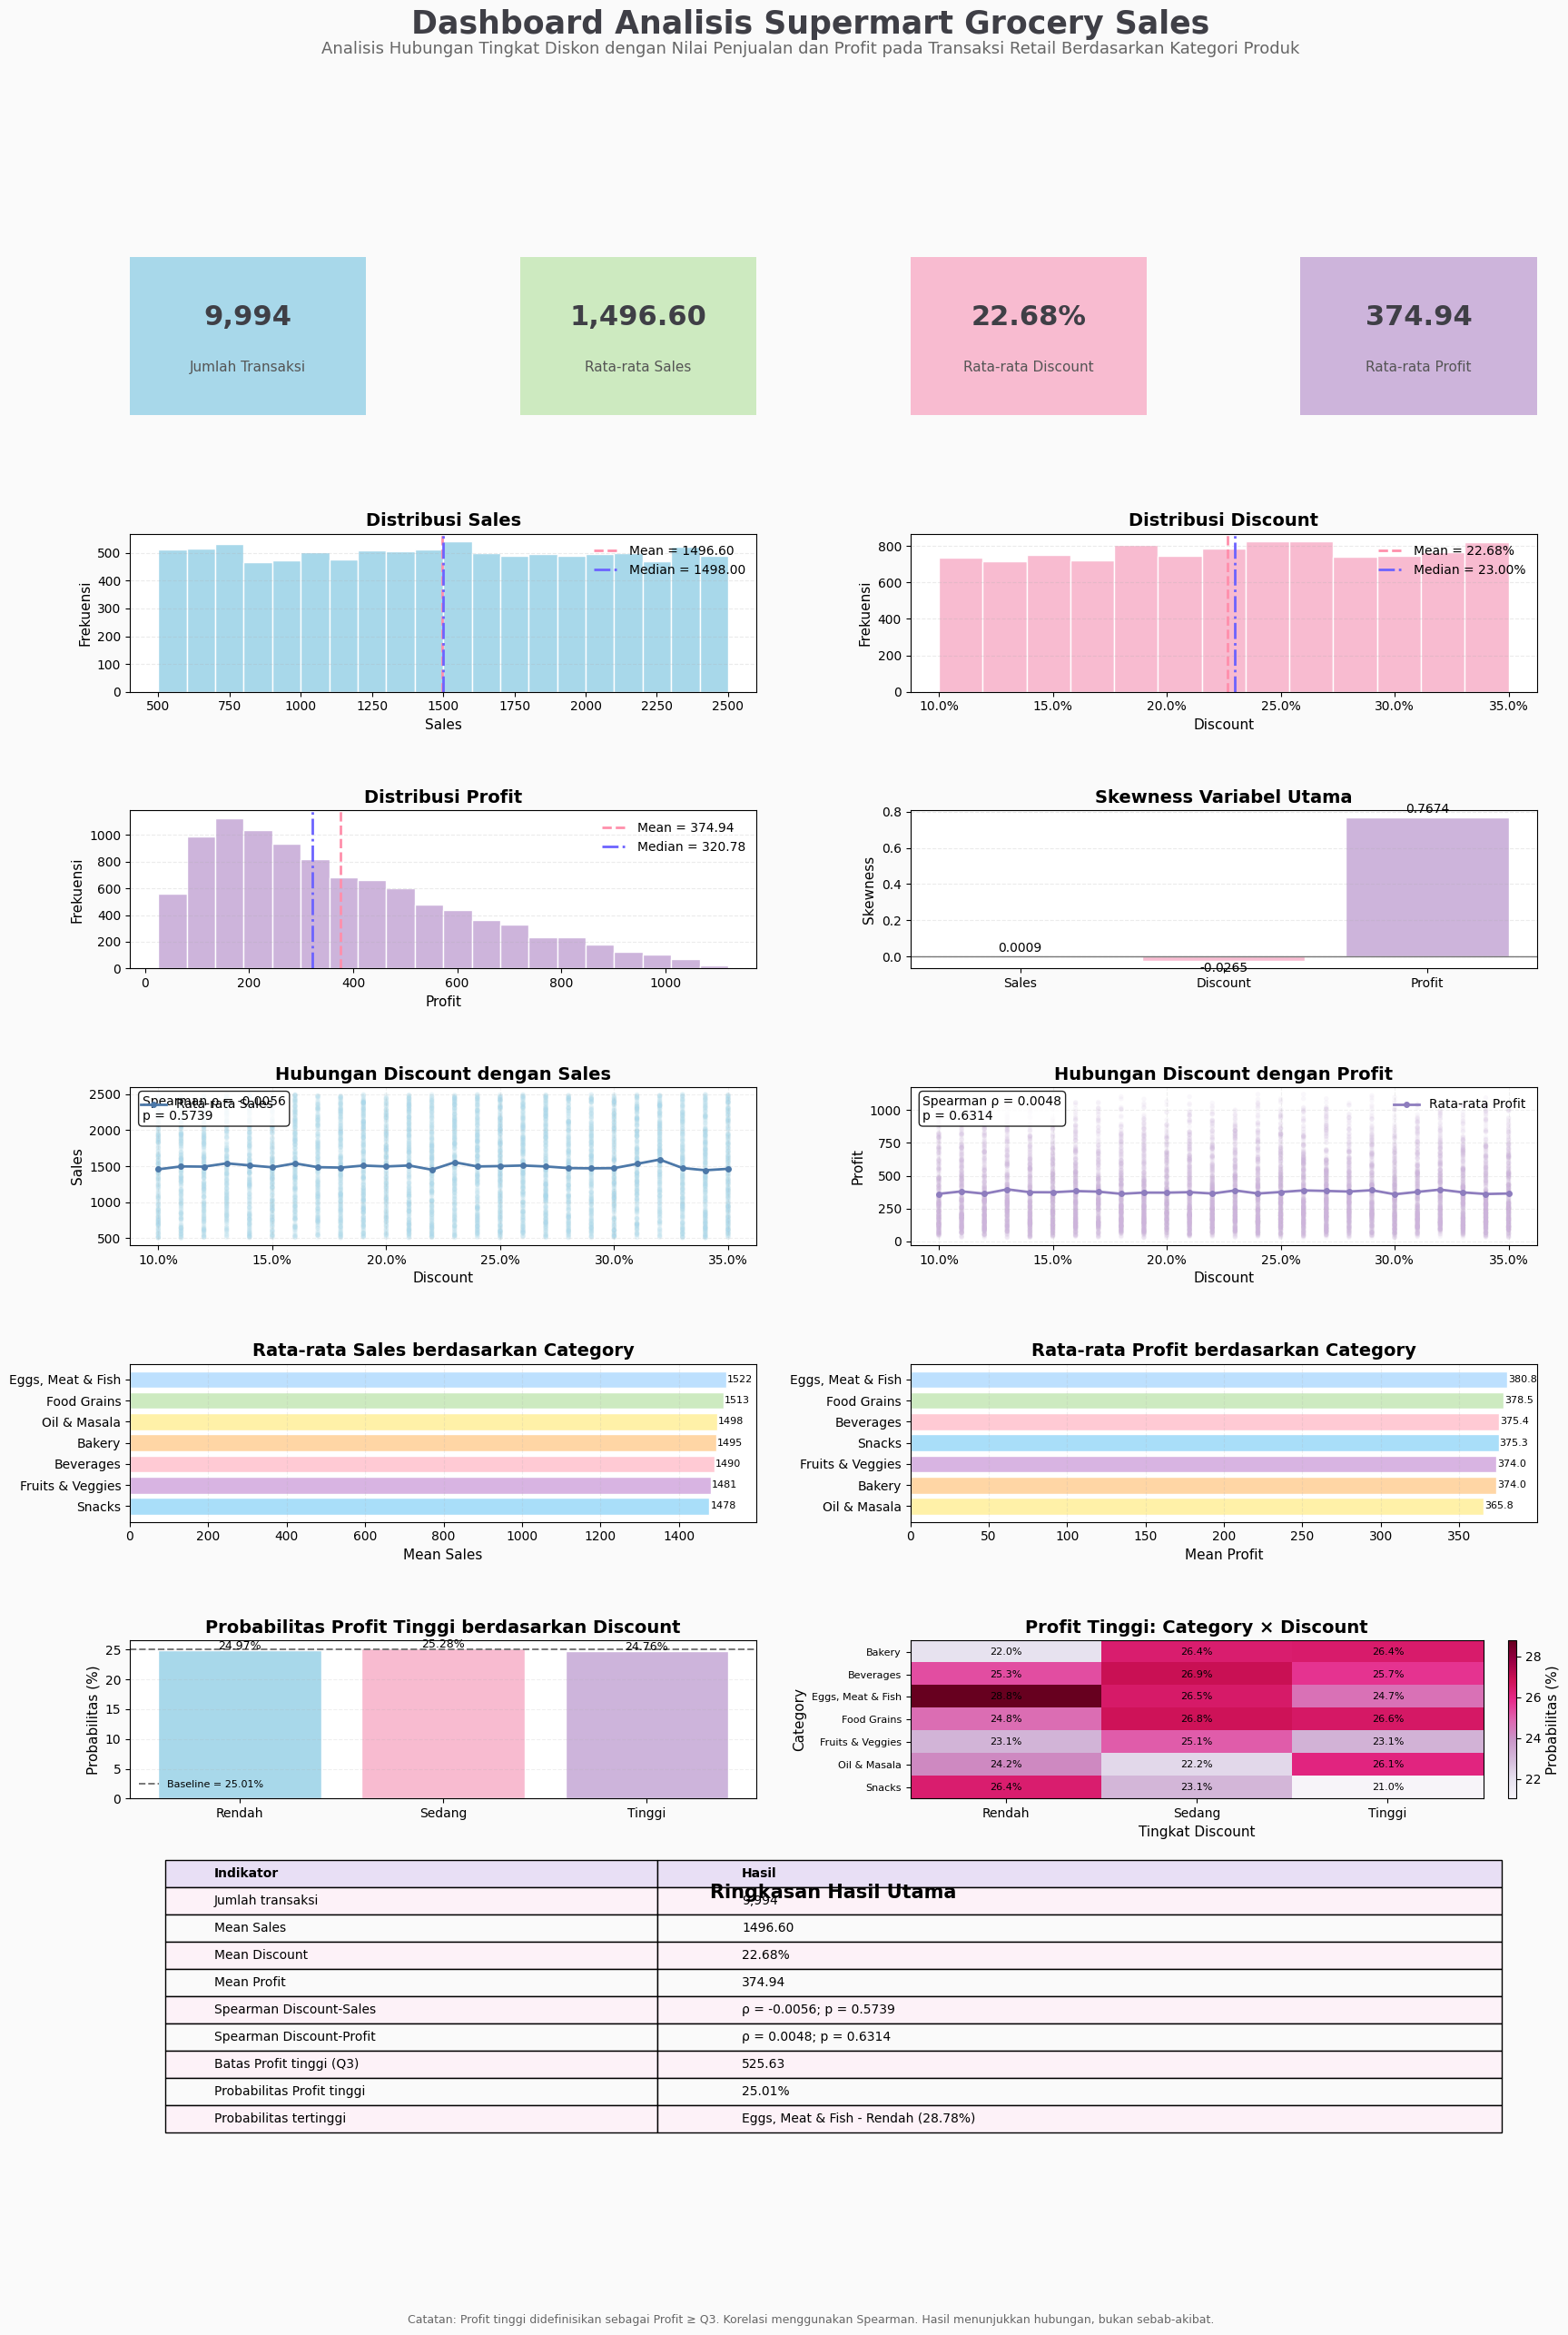

Dashboard berhasil disimpan di: output_grafik/dashboard_analisis_final.png


In [ ]:
# ============================================================
# DASHBOARD RINGKASAN ANALISIS
# Analisis Hubungan Tingkat Diskon dengan Nilai Penjualan
# dan Profit pada Transaksi Retail Berdasarkan Kategori Produk
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from matplotlib.ticker import PercentFormatter
from matplotlib.gridspec import GridSpec


# ============================================================
# 1. PERSIAPAN DATA
# ============================================================

dashboard_df = df.copy()

# Warna pastel utama
warna_sales = "#A8D8EA"       # biru pastel
warna_discount = "#F8BBD0"    # pink pastel
warna_profit = "#CDB4DB"      # ungu pastel
warna_pink = "#FFB3C6"
warna_hijau = "#CDEAC0"
warna_kuning = "#FFF1A8"
warna_teks = "#3F3F46"
warna_grid = "#D4D4D8"

# Warna Category
warna_category = {
    "Bakery": "#FFD6A5",
    "Beverages": "#FFCAD4",
    "Eggs, Meat & Fish": "#BDE0FE",
    "Food Grains": "#CDEAC0",
    "Fruits & Veggies": "#D8B4E2",
    "Oil & Masala": "#FFF1A8",
    "Snacks": "#A9DEF9"
}


# ============================================================
# 2. PERHITUNGAN UTAMA
# ============================================================

# Statistik deskriptif
mean_sales = dashboard_df["Sales"].mean()
median_sales = dashboard_df["Sales"].median()

mean_discount = dashboard_df["Discount"].mean()
median_discount = dashboard_df["Discount"].median()

mean_profit = dashboard_df["Profit"].mean()
median_profit = dashboard_df["Profit"].median()

# Skewness
skew_sales = dashboard_df["Sales"].skew()
skew_discount = dashboard_df["Discount"].skew()
skew_profit = dashboard_df["Profit"].skew()

# Korelasi Spearman
rho_sales, p_sales = spearmanr(
    dashboard_df["Discount"],
    dashboard_df["Sales"]
)

rho_profit, p_profit = spearmanr(
    dashboard_df["Discount"],
    dashboard_df["Profit"]
)

# Profit tinggi berdasarkan Q3
q3_profit = dashboard_df["Profit"].quantile(0.75)

dashboard_df["Profit_Tinggi"] = (
    dashboard_df["Profit"] >= q3_profit
)

prob_profit_tinggi = dashboard_df["Profit_Tinggi"].mean()

# Kelompok Discount berdasarkan tertil
dashboard_df["Tingkat_Discount"] = pd.qcut(
    dashboard_df["Discount"],
    q=3,
    labels=["Rendah", "Sedang", "Tinggi"]
)

# Ringkasan Category
summary_category = (
    dashboard_df
    .groupby("Category")
    .agg(
        N=("Order ID", "count"),
        Mean_Sales=("Sales", "mean"),
        Mean_Discount=("Discount", "mean"),
        Mean_Profit=("Profit", "mean")
    )
    .reset_index()
)

# Mean Sales berdasarkan Discount
mean_sales_discount = (
    dashboard_df
    .groupby("Discount", as_index=False)["Sales"]
    .mean()
)

# Mean Profit berdasarkan Discount
mean_profit_discount = (
    dashboard_df
    .groupby("Discount", as_index=False)["Profit"]
    .mean()
)

# Probabilitas berdasarkan tingkat Discount
prob_discount = (
    dashboard_df
    .groupby(
        "Tingkat_Discount",
        observed=True
    )["Profit_Tinggi"]
    .mean()
    .reindex(["Rendah", "Sedang", "Tinggi"])
)

# Probabilitas berdasarkan Category + Discount
prob_conditional = (
    dashboard_df
    .groupby(
        ["Category", "Tingkat_Discount"],
        observed=True
    )["Profit_Tinggi"]
    .mean()
    .reset_index(name="Probabilitas")
)

tabel_probabilitas = (
    prob_conditional
    .pivot(
        index="Category",
        columns="Tingkat_Discount",
        values="Probabilitas"
    )
    .reindex(
        columns=["Rendah", "Sedang", "Tinggi"]
    )
    * 100
)

# Kombinasi probabilitas tertinggi
kombinasi_max = prob_conditional.loc[
    prob_conditional["Probabilitas"].idxmax()
]


# ============================================================
# 3. MEMBUAT DASHBOARD
# ============================================================

fig = plt.figure(
    figsize=(20, 26),
    facecolor="#FAFAFA"
)

gs = GridSpec(
    7,
    4,
    figure=fig,
    hspace=0.75,
    wspace=0.65
)

fig.suptitle(
    "Dashboard Analisis Supermart Grocery Sales",
    fontsize=25,
    fontweight="bold",
    color=warna_teks,
    y=0.985
)

fig.text(
    0.5,
    0.966,
    "Analisis Hubungan Tingkat Diskon dengan Nilai Penjualan dan Profit "
    "pada Transaksi Retail Berdasarkan Kategori Produk",
    ha="center",
    fontsize=13,
    color="#666666"
)


# ============================================================
# 4. KPI CARDS
# ============================================================

cards = [
    (
        "Jumlah Transaksi",
        f"{len(dashboard_df):,}",
        warna_sales
    ),
    (
        "Rata-rata Sales",
        f"{mean_sales:,.2f}",
        warna_hijau
    ),
    (
        "Rata-rata Discount",
        f"{mean_discount:.2%}",
        warna_discount
    ),
    (
        "Rata-rata Profit",
        f"{mean_profit:,.2f}",
        warna_profit
    )
]

for i, (judul, nilai, warna) in enumerate(cards):

    ax = fig.add_subplot(gs[0, i])

    ax.set_facecolor(warna)

    ax.text(
        0.5,
        0.62,
        nilai,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color=warna_teks
    )

    ax.text(
        0.5,
        0.30,
        judul,
        ha="center",
        va="center",
        fontsize=11,
        color="#555555"
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


# ============================================================
# 5. HISTOGRAM SALES
# ============================================================

ax1 = fig.add_subplot(gs[1, 0:2])

ax1.hist(
    dashboard_df["Sales"],
    bins=20,
    color=warna_sales,
    edgecolor="white",
    linewidth=1
)

ax1.axvline(
    mean_sales,
    linestyle="--",
    linewidth=2,
    color="#FF8FAB",
    label=f"Mean = {mean_sales:.2f}"
)

ax1.axvline(
    median_sales,
    linestyle="-.",
    linewidth=2,
    color="#6C63FF",
    label=f"Median = {median_sales:.2f}"
)

ax1.set_title(
    "Distribusi Sales",
    fontweight="bold"
)

ax1.set_xlabel("Sales")
ax1.set_ylabel("Frekuensi")
ax1.legend(frameon=False)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


# ============================================================
# 6. HISTOGRAM DISCOUNT
# ============================================================

ax2 = fig.add_subplot(gs[1, 2:4])

ax2.hist(
    dashboard_df["Discount"],
    bins=13,
    color=warna_discount,
    edgecolor="white"
)

ax2.axvline(
    mean_discount,
    linestyle="--",
    linewidth=2,
    color="#FF8FAB",
    label=f"Mean = {mean_discount:.2%}"
)

ax2.axvline(
    median_discount,
    linestyle="-.",
    linewidth=2,
    color="#6C63FF",
    label=f"Median = {median_discount:.2%}"
)

ax2.xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

ax2.set_title(
    "Distribusi Discount",
    fontweight="bold"
)

ax2.set_xlabel("Discount")
ax2.set_ylabel("Frekuensi")
ax2.legend(frameon=False)

ax2.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


# ============================================================
# 7. HISTOGRAM PROFIT
# ============================================================

ax3 = fig.add_subplot(gs[2, 0:2])

ax3.hist(
    dashboard_df["Profit"],
    bins=20,
    color=warna_profit,
    edgecolor="white"
)

ax3.axvline(
    mean_profit,
    linestyle="--",
    linewidth=2,
    color="#FF8FAB",
    label=f"Mean = {mean_profit:.2f}"
)

ax3.axvline(
    median_profit,
    linestyle="-.",
    linewidth=2,
    color="#6C63FF",
    label=f"Median = {median_profit:.2f}"
)

ax3.set_title(
    "Distribusi Profit",
    fontweight="bold"
)

ax3.set_xlabel("Profit")
ax3.set_ylabel("Frekuensi")
ax3.legend(frameon=False)

ax3.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


# ============================================================
# 8. SKEWNESS
# ============================================================

ax4 = fig.add_subplot(gs[2, 2:4])

variabel_skew = [
    "Sales",
    "Discount",
    "Profit"
]

nilai_skew = [
    skew_sales,
    skew_discount,
    skew_profit
]

bars = ax4.bar(
    variabel_skew,
    nilai_skew,
    color=[
        warna_sales,
        warna_discount,
        warna_profit
    ],
    edgecolor="white"
)

ax4.axhline(
    0,
    color="#777777",
    linewidth=1
)

for bar, nilai in zip(
    bars,
    nilai_skew
):
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        nilai + (0.025 if nilai >= 0 else -0.06),
        f"{nilai:.4f}",
        ha="center",
        fontsize=10
    )

ax4.set_title(
    "Skewness Variabel Utama",
    fontweight="bold"
)

ax4.set_ylabel("Skewness")

ax4.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


# ============================================================
# 9. HUBUNGAN DISCOUNT - SALES
# ============================================================

ax5 = fig.add_subplot(gs[3, 0:2])

ax5.scatter(
    dashboard_df["Discount"],
    dashboard_df["Sales"],
    color=warna_sales,
    alpha=0.10,
    s=15,
    edgecolors="none"
)

ax5.plot(
    mean_sales_discount["Discount"],
    mean_sales_discount["Sales"],
    color="#4C78A8",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Rata-rata Sales"
)

ax5.xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

ax5.set_title(
    "Hubungan Discount dengan Sales",
    fontweight="bold"
)

ax5.set_xlabel("Discount")
ax5.set_ylabel("Sales")

ax5.text(
    0.02,
    0.95,
    f"Spearman ρ = {rho_sales:.4f}\np = {p_sales:.4f}",
    transform=ax5.transAxes,
    va="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

ax5.grid(
    linestyle="--",
    alpha=0.2
)

ax5.legend(frameon=False)


# ============================================================
# 10. HUBUNGAN DISCOUNT - PROFIT
# ============================================================

ax6 = fig.add_subplot(gs[3, 2:4])

ax6.scatter(
    dashboard_df["Discount"],
    dashboard_df["Profit"],
    color=warna_profit,
    alpha=0.10,
    s=15,
    edgecolors="none"
)

ax6.plot(
    mean_profit_discount["Discount"],
    mean_profit_discount["Profit"],
    color="#8E7DBE",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Rata-rata Profit"
)

ax6.xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

ax6.set_title(
    "Hubungan Discount dengan Profit",
    fontweight="bold"
)

ax6.set_xlabel("Discount")
ax6.set_ylabel("Profit")

ax6.text(
    0.02,
    0.95,
    f"Spearman ρ = {rho_profit:.4f}\np = {p_profit:.4f}",
    transform=ax6.transAxes,
    va="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

ax6.grid(
    linestyle="--",
    alpha=0.2
)

ax6.legend(frameon=False)


# ============================================================
# 11. MEAN SALES BERDASARKAN CATEGORY
# ============================================================

ax7 = fig.add_subplot(gs[4, 0:2])

plot_sales = (
    summary_category
    .sort_values("Mean_Sales")
)

colors_sales = [
    warna_category[k]
    for k in plot_sales["Category"]
]

bars = ax7.barh(
    plot_sales["Category"],
    plot_sales["Mean_Sales"],
    color=colors_sales,
    edgecolor="white"
)

for bar, nilai in zip(
    bars,
    plot_sales["Mean_Sales"]
):
    ax7.text(
        nilai + 2,
        bar.get_y() + bar.get_height()/2,
        f"{nilai:.0f}",
        va="center",
        fontsize=8
    )

ax7.set_title(
    "Rata-rata Sales berdasarkan Category",
    fontweight="bold"
)

ax7.set_xlabel("Mean Sales")

ax7.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)


# ============================================================
# 12. MEAN PROFIT BERDASARKAN CATEGORY
# ============================================================

ax8 = fig.add_subplot(gs[4, 2:4])

plot_profit = (
    summary_category
    .sort_values("Mean_Profit")
)

colors_profit = [
    warna_category[k]
    for k in plot_profit["Category"]
]

bars = ax8.barh(
    plot_profit["Category"],
    plot_profit["Mean_Profit"],
    color=colors_profit,
    edgecolor="white"
)

for bar, nilai in zip(
    bars,
    plot_profit["Mean_Profit"]
):
    ax8.text(
        nilai + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{nilai:.1f}",
        va="center",
        fontsize=8
    )

ax8.set_title(
    "Rata-rata Profit berdasarkan Category",
    fontweight="bold"
)

ax8.set_xlabel("Mean Profit")

ax8.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)


# ============================================================
# 13. PROBABILITAS PROFIT TINGGI BERDASARKAN DISCOUNT
# ============================================================

ax9 = fig.add_subplot(gs[5, 0:2])

tingkat = [
    "Rendah",
    "Sedang",
    "Tinggi"
]

nilai_prob = [
    prob_discount["Rendah"] * 100,
    prob_discount["Sedang"] * 100,
    prob_discount["Tinggi"] * 100
]

bars = ax9.bar(
    tingkat,
    nilai_prob,
    color=[
        warna_sales,
        warna_discount,
        warna_profit
    ],
    edgecolor="white"
)

ax9.axhline(
    prob_profit_tinggi * 100,
    color="#777777",
    linestyle="--",
    linewidth=1.4,
    label=f"Baseline = {prob_profit_tinggi:.2%}"
)

for bar, nilai in zip(
    bars,
    nilai_prob
):
    ax9.text(
        bar.get_x() + bar.get_width()/2,
        nilai + 0.10,
        f"{nilai:.2f}%",
        ha="center",
        fontsize=9
    )

ax9.set_title(
    "Probabilitas Profit Tinggi berdasarkan Discount",
    fontweight="bold"
)

ax9.set_ylabel("Probabilitas (%)")

ax9.legend(
    frameon=False,
    fontsize=8
)

ax9.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)


# ============================================================
# 14. HEATMAP PROBABILITAS
# ============================================================

ax10 = fig.add_subplot(gs[5, 2:4])

matrix_prob = tabel_probabilitas.values

gambar = ax10.imshow(
    matrix_prob,
    cmap="PuRd",
    aspect="auto"
)

ax10.set_xticks(
    range(len(tabel_probabilitas.columns))
)

ax10.set_xticklabels(
    tabel_probabilitas.columns
)

ax10.set_yticks(
    range(len(tabel_probabilitas.index))
)

ax10.set_yticklabels(
    tabel_probabilitas.index,
    fontsize=8
)

for i in range(
    len(tabel_probabilitas.index)
):
    for j in range(
        len(tabel_probabilitas.columns)
    ):
        ax10.text(
            j,
            i,
            f"{matrix_prob[i, j]:.1f}%",
            ha="center",
            va="center",
            fontsize=8
        )

ax10.set_title(
    "Profit Tinggi: Category × Discount",
    fontweight="bold"
)

ax10.set_xlabel("Tingkat Discount")
ax10.set_ylabel("Category")

cbar = fig.colorbar(
    gambar,
    ax=ax10,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Probabilitas (%)"
)


# ============================================================
# 15. TABEL RINGKASAN HASIL
# ============================================================

ax11 = fig.add_subplot(gs[6, :])
ax11.axis("off")

data_tabel = [
    [
        "Jumlah transaksi",
        f"{len(dashboard_df):,}"
    ],
    [
        "Mean Sales",
        f"{mean_sales:.2f}"
    ],
    [
        "Mean Discount",
        f"{mean_discount:.2%}"
    ],
    [
        "Mean Profit",
        f"{mean_profit:.2f}"
    ],
    [
        "Spearman Discount-Sales",
        f"ρ = {rho_sales:.4f}; p = {p_sales:.4f}"
    ],
    [
        "Spearman Discount-Profit",
        f"ρ = {rho_profit:.4f}; p = {p_profit:.4f}"
    ],
    [
        "Batas Profit tinggi (Q3)",
        f"{q3_profit:.2f}"
    ],
    [
        "Probabilitas Profit tinggi",
        f"{prob_profit_tinggi:.2%}"
    ],
    [
        "Probabilitas tertinggi",
        (
            f"{kombinasi_max['Category']} - "
            f"{kombinasi_max['Tingkat_Discount']} "
            f"({kombinasi_max['Probabilitas']:.2%})"
        )
    ]
]

tabel = ax11.table(
    cellText=data_tabel,
    colLabels=[
        "Indikator",
        "Hasil"
    ],
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.35, 0.60]
)

tabel.auto_set_font_size(False)
tabel.set_fontsize(10)
tabel.scale(1, 1.8)

# Header tabel
for j in range(2):
    tabel[(0, j)].set_facecolor(
        "#E8DFF5"
    )
    tabel[(0, j)].set_text_props(
        fontweight="bold"
    )

# Baris alternating pastel
for i in range(1, len(data_tabel) + 1):

    warna_baris = (
        "#FAFAFA"
        if i % 2 == 0
        else "#FDF2F8"
    )

    for j in range(2):
        tabel[(i, j)].set_facecolor(
            warna_baris
        )

ax11.set_title(
    "Ringkasan Hasil Utama",
    fontsize=15,
    fontweight="bold",
    pad=15
)


# ============================================================
# 16. FOOTNOTE
# ============================================================

fig.text(
    0.5,
    0.005,
    (
        "Catatan: Profit tinggi didefinisikan sebagai Profit ≥ Q3. "
        "Korelasi menggunakan Spearman. "
        "Hasil menunjukkan hubungan, bukan sebab-akibat."
    ),
    ha="center",
    fontsize=9,
    color="#666666"
)


# ============================================================
# 17. SIMPAN DASHBOARD
# ============================================================

os.makedirs(
    "output_grafik",
    exist_ok=True
)

plt.savefig(
    "output_grafik/dashboard_analisis_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(
    "Dashboard berhasil disimpan di: "
    "output_grafik/dashboard_analisis_final.png"
)